<a href="https://colab.research.google.com/github/OdysseusPolymetis/tragic_influence_Litterature/blob/main/tragic_influence_crossencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Détection d'intertexte Sénèque ↔ tragiques grecs

## Pipeline propre avec spécificité auteur, alignement token-level et cross-encoder supervisé

Architecture conservée :

1. **Chargement des corpus Perseus** sans modification du parcours des fichiers ni de la constitution du corpus.
2. **Spécificité auteur grecque** avec GreBerta sur les chunks de tours de parole.
3. **Préfiltrage token-level** avec PhilBERTa, incluant la cohérence de champ sémantique croisé latin-grec.
4. **Reranking phrase-level** avec SPhilBERTa.
5. **Pénalisation cross-encoder** appliquée avant les inspections, visualisations et exports.

Le cross-encoder est utilisé comme **poids négatif** : il ne rehausse pas artificiellement les candidats ; il diminue seulement le score des rapprochements que le modèle supervisé juge faibles. Les visualisations et exports utilisent donc par défaut `final_score_ce` et `specificity_adjusted_score_ce`, tout en conservant les scores antérieurs (`final_score`, `specificity_adjusted_score`) pour comparaison.


## Imports


In [39]:
import os
import re
import math
import json
import shutil
import random
import unicodedata
from pathlib import Path
from collections import Counter, defaultdict
from copy import deepcopy

import numpy as np
import pandas as pd

from tqdm.auto import tqdm
from lxml import etree

import torch
import torch.nn.functional as F

from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModel, AutoModelForMaskedLM

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import classification_report, confusion_matrix


## Configuration


In [92]:
BASE_DIR = Path("/content")

GREEK_REPO  = BASE_DIR / "canonical-greekLit"  / "data"
LATIN_REPO  = BASE_DIR / "canonical-latinLit"  / "data"

CACHE_DIR   = BASE_DIR / "cache_tragic_influence"
RESULTS_DIR = BASE_DIR / "results_tragic_influence"
CACHE_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ── Modèles ──────────────────────────────────────────────────────────────────
SEGMENT_MODEL_NAME     = "bowphs/SPhilBerta"
SEGMENT_MODEL_LABEL    = "SPhilBerta"

SPECIFICITY_MODEL_NAME    = "bowphs/GreBerta"
SPECIFICITY_TOKENIZER_NAME = None
SPECIFICITY_MODEL_BACKEND  = "hf_mean_pooling"
SPECIFICITY_UNIT           = "speech_turn_chunks_70"
SPECIFICITY_MODEL_LABEL    = (
    SPECIFICITY_MODEL_NAME.replace("/", "_")
    + "__unit_" + SPECIFICITY_UNIT
)

TOKEN_MODEL_NAME  = "bowphs/PhilBerta"
TOKEN_MODEL_LABEL = "PhilBerta"
TOKEN_MAX_LENGTH  = 256

# ── Segmentation ─────────────────────────────────────────────────────────────
SENTENCE_MIN_WORDS = 5
SENTENCE_MAX_WORDS = 80
TURN_MIN_WORDS     = 5
TURN_MAX_WORDS     = 70

# ── Encodage ─────────────────────────────────────────────────────────────────
ENCODE_BATCH_SIZE = 64
MAX_LENGTH        = 256

# ── Classifieurs de spécificité ───────────────────────────────────────────────
N_SPLITS        = 5
RANDOM_STATE    = 42
MAX_REFERENCE_SEGMENTS_PER_GROUP = 6000

# Seuil assoupli : utilisé comme pondération downstream, pas comme filtre dur.
# Valeur v1 = 0.75 ; v2 = 0.50 (meilleur rappel, pénalisation via specificity_weight).
SPECIFICITY_QUANTILE = 0.50

# ── Filtrage token-level ──────────────────────────────────────────────────────
TOKEN_TOP_N_PER_SOURCE   = 25
TOKEN_MIN_CHARS          = 5

TOKEN_SIM_THRESHOLD           = 0.70
TOKEN_MIN_STRONG_MATCHES      = 3
TOKEN_MIN_MEAN_STRONG_ALIGNMENT = 0.70
TOKEN_MIN_ABSOLUTE_SCORE       = 0.25
TOKEN_MIN_COVERAGE_SOURCE      = 0.00
TOKEN_MIN_COVERAGE_TARGET      = 0.00

TOKEN_FIELD_SIM_THRESHOLD   = 0.68
TOKEN_FIELD_TOP_K_PER_TOKEN = 3
TOKEN_MIN_FIELD_ALIGNMENTS  = 5
TOKEN_MIN_FIELD_COHERENCE   = 0.50
TOKEN_MIN_FIELD_MEAN_SIMILARITY = 0.70

TOKEN_COMPOSITE_WEIGHTS = {
    "token_alignment_score":    0.30,
    "mean_strong_alignment":    0.25,
    "semantic_field_coherence": 0.30,
    "token_coverage":           0.15,
}

# ── Reranking final ───────────────────────────────────────────────────────────
SENTENCE_SIM_THRESHOLD         = 0.70
FINAL_TOP_N_PER_SOURCE         = 30
HUB_RATE_MAX                   = 0.15
MAX_TOKEN_CANDIDATES_PER_SOURCE = 20

print("Device :", DEVICE)
print("Spécificité :", SPECIFICITY_MODEL_LABEL)
print("Reranking  :", SEGMENT_MODEL_LABEL)
print("Token      :", TOKEN_MODEL_LABEL)

# ── Cross-encoder supervisé ───────────────────────────────────────────────────
# Les fichiers auxiliaires sont téléchargés depuis le dépôt GitHub vers /content,
# afin de conserver les chemins attendus par extract_training_pairs.py et
# finetune_crossencoder.py.
AUX_REPO_RAW = "https://raw.githubusercontent.com/OdysseusPolymetis/tragic_influence_Litterature/main"

CROSS_ENCODER_DIR = BASE_DIR / "crossencoder_philbert_seneca"
CROSS_ENCODER_MAX_LENGTH = 256
FORCE_RETRAIN_CROSS_ENCODER = False

# Poids négatif : le cross-encoder ne booste pas ; il pénalise les candidats
# dont le score supervisé est faible.
CROSS_ENCODER_LOW_SCORE_THRESHOLD = 0.25
CROSS_ENCODER_NEGATIVE_WEIGHT = 0.30


Device : cuda
Spécificité : bowphs_GreBerta__unit_speech_turn_chunks_70
Reranking  : SPhilBerta
Token      : PhilBerta


## Définition des corpus


In [41]:
greek_tragedians = {
    "sophocles": ["tlg0011"],
    "aeschylus": ["tlg0085"],
    "euripides": ["tlg0006"],
}

dramatic_reference = {
    "comedy":        ["tlg0019", "tlg0039"],
    "epic_related":  ["tlg0007"],
}

non_dramatic_reference = {
    "historiography": ["tlg0016", "tlg0525"],
    "philosophy":     ["tlg0059", "tlg0559"],
}

seneca_tragedies = {
    "phi001": "Hercules Furens",
    "phi002": "Troades",
    "phi003": "Phoenissae",
    "phi004": "Medea",
    "phi005": "Phaedra",
    "phi006": "Oedipus",
    "phi007": "Agamemnon",
    "phi008": "Thyestes",
    "phi009": "Hercules Oetaeus",
    "phi010": "Octavia",
}

print("Tragiques grecs :", list(greek_tragedians.keys()))
print("Référence dramatique :", list(dramatic_reference.keys()))
print("Référence non dramatique :", list(non_dramatic_reference.keys()))
print("Tragédies de Sénèque :", len(seneca_tragedies))


Tragiques grecs : ['sophocles', 'aeschylus', 'euripides']
Référence dramatique : ['comedy', 'epic_related']
Référence non dramatique : ['historiography', 'philosophy']
Tragédies de Sénèque : 10


In [42]:
# Clonage des dépôts Perseus dans /content, en conservant les chemins attendus.
# Cellule idempotente : si les dépôts existent déjà, on ne les reclone pas.
import subprocess

if not LATIN_REPO.parent.exists():
    subprocess.run(
        ["git", "clone", "https://github.com/PerseusDL/canonical-latinLit.git", str(LATIN_REPO.parent)],
        check=True,
    )
else:
    print("Dépôt latin déjà présent :", LATIN_REPO.parent)

if not GREEK_REPO.parent.exists():
    subprocess.run(
        ["git", "clone", "https://github.com/PerseusDL/canonical-greekLit.git", str(GREEK_REPO.parent)],
        check=True,
    )
else:
    print("Dépôt grec déjà présent :", GREEK_REPO.parent)


Dépôt latin déjà présent : /content/canonical-latinLit
Dépôt grec déjà présent : /content/canonical-greekLit


## Utilitaires TEI


In [43]:
TEI_NS = {"tei": "http://www.tei-c.org/ns/1.0"}
TEI_TAGS_TO_EXCLUDE_FROM_TEXT    = {"speaker"}
TEI_TAGS_TO_EXCLUDE_IN_SEGMENTS  = {"speaker", "stage", "note"}


def normalize_space(text):
    return re.sub(r"\s+", " ", str(text)).strip()


def remove_elements_preserve_tail(root, tag_names):
    """Supprime des éléments TEI en préservant leur tail text."""
    for tag_name in tag_names:
        for el in root.xpath(f".//*[local-name()='{tag_name}']"):
            parent = el.getparent()
            if parent is None:
                continue
            tail = el.tail
            prev = el.getprevious()
            parent.remove(el)
            if tail:
                if prev is not None:
                    prev.tail = (prev.tail or "") + tail
                else:
                    parent.text = (parent.text or "") + tail


def parse_tei_body(xml_path, exclude_tags=TEI_TAGS_TO_EXCLUDE_FROM_TEXT):
    parser = etree.XMLParser(recover=True)
    tree   = etree.parse(str(xml_path), parser)
    body   = tree.find(".//tei:body", namespaces=TEI_NS)
    if body is None:
        return ""
    body = deepcopy(body)
    if exclude_tags:
        remove_elements_preserve_tail(body, exclude_tags)
    return " ".join(t.strip() for t in body.itertext() if t and t.strip())


def extract_tei_title(xml_path):
    parser = etree.XMLParser(recover=True)
    tree   = etree.parse(str(xml_path), parser)
    el     = tree.find(".//tei:titleStmt/tei:title", namespaces=TEI_NS)
    if el is not None:
        t = " ".join(el.itertext()).strip()
        if t:
            return t
    return Path(xml_path).stem


def normalize_text(text):
    """Normalisation : on conserve les diacritiques grecs."""
    if not text:
        return ""
    text = unicodedata.normalize("NFC", text)
    text = text.lower()
    text = re.sub(r"[\[\]{}()<>]",            " ", text)
    text = re.sub(r"\d+",                       " ", text)
    text = re.sub(r'["""''.,;:!?·…—–\\/_|*=+#-]', " ", text)
    text = re.sub(r"\s+",                       " ", text).strip()
    return text


def text_from_element_without_excluded_tags(element):
    el = deepcopy(element)
    remove_elements_preserve_tail(el, TEI_TAGS_TO_EXCLUDE_IN_SEGMENTS)
    return normalize_space(" ".join(t.strip() for t in el.itertext() if t and t.strip()))


def get_speaker_text(sp_element):
    speaker = sp_element.find(".//tei:speaker", namespaces=TEI_NS)
    return normalize_space(" ".join(speaker.itertext())) if speaker is not None else ""


def word_count(text):
    return len(str(text).split())


def split_long_text_by_words(text, max_words=70, min_words=5):
    words = str(text).split()
    if len(words) < min_words:
        return []
    return [
        " ".join(words[i:i + max_words])
        for i in range(0, len(words), max_words)
        if len(words[i:i + max_words]) >= min_words
    ]


## Segmentation en phrases
### Règle : le point médian grec `·` n'est **pas** une frontière de phrase

En grec antique, `·` (U+00B7 / U+0387) est une ponctuation de niveau *colon* —
l'équivalent d'un point-virgule, pas d'un point final. L'utiliser comme coupure
surframente les tours de parole. On réserve donc les frontières dures (`.!?;`)
pour les deux langues, et on n'ajoute `·` que pour le latin normalisé.


In [44]:
def simple_tokenize(text):
    if not isinstance(text, str):
        return []
    return [tok for tok in text.split() if tok.strip()]


def split_on_sentence_punctuation(text, lang="latin"):
    """
    Découpe un texte brut en phrases.

    - Pour le latin (et par défaut) : on coupe sur . ! ? ; · ·
    - Pour le grec : on exclut · (point médian) qui n'est pas une frontière de phrase.
    """
    if not isinstance(text, str):
        return []

    if lang == "greek":
        parts = re.split(r"[.!?;]+", text)
    else:
        parts = re.split(r"[.!?;··]+", text)

    sentences = []
    for part in parts:
        sent = normalize_text(part)
        if sent:
            sentences.append(sent)
    return sentences


def segment_text_sentences(text, min_words=5, max_words=80, lang="latin"):
    sentences = split_on_sentence_punctuation(text, lang=lang)
    out = []
    for sent in sentences:
        words = simple_tokenize(sent)
        if len(words) < min_words:
            continue
        if len(words) <= max_words:
            out.append(sent)
        else:
            for i in range(0, len(words), max_words):
                chunk = words[i:i + max_words]
                if len(chunk) >= min_words:
                    out.append(" ".join(chunk))
    return out


def build_sentence_segments_df(works_df, text_col="raw_text", min_words=5, max_words=80, lang="latin"):
    rows = []
    for _, row in tqdm(works_df.iterrows(), total=len(works_df), desc="Sentence segmentation"):
        segments = segment_text_sentences(row[text_col], min_words=min_words, max_words=max_words, lang=lang)
        for idx, seg in enumerate(segments):
            rows.append({
                "corpus_type":   row["corpus_type"],
                "author_group":  row["author_group"],
                "author_id":     row["author_id"],
                "work_id":       row["work_id"],
                "work_label":    row["work_label"],
                "lang":          row["lang"],
                "xml_path":      row["xml_path"],
                "segment_level": "sentence",
                "segment_idx":   idx,
                "segment_id":    f"{row['author_id']}.{row['work_id']}::sent::{idx}",
                "segment_text":  seg,
            })
    return pd.DataFrame(rows)


## Segmentation grecque en deux niveaux (chunks `<sp>` → phrases héritées)


In [45]:
def parse_tei_as_speech_turn_chunks(xml_path, min_words=TURN_MIN_WORDS, max_words=TURN_MAX_WORDS):
    """
    Extrait les tours de parole <sp>.
    - Contenu de <speaker> retiré.
    - Longs tours découpés en chunks.
    - Fallback sur le body si aucun <sp> (loggé explicitement).
    """
    parser = etree.XMLParser(recover=True)
    tree   = etree.parse(str(xml_path), parser)
    body   = tree.find(".//tei:body", namespaces=TEI_NS)
    if body is None:
        return []

    sp_elements = body.findall(".//tei:sp", namespaces=TEI_NS)
    segments = []

    if sp_elements:
        for turn_idx, sp in enumerate(sp_elements):
            speaker   = get_speaker_text(sp)
            who       = sp.get("who", "")
            turn_text = text_from_element_without_excluded_tags(sp)
            chunks    = split_long_text_by_words(turn_text, max_words=max_words, min_words=min_words)
            for chunk_idx, chunk in enumerate(chunks):
                segments.append({
                    "segment_type":   "sp_chunk",
                    "turn_idx":       turn_idx,
                    "turn_chunk_idx": chunk_idx,
                    "speaker":        speaker,
                    "who":            who,
                    "segment_text":   chunk,
                    "n_words":        word_count(chunk),
                })
        return segments

    # ── Fallback ──────────────────────────────────────────────────────────────
    print(f"[FALLBACK] Aucun <sp> dans {Path(xml_path).name} — découpage body brut")
    body_copy = deepcopy(body)
    remove_elements_preserve_tail(body_copy, TEI_TAGS_TO_EXCLUDE_IN_SEGMENTS)
    body_text = normalize_space(" ".join(
        t.strip() for t in body_copy.itertext() if t and t.strip()
    ))
    chunks = split_long_text_by_words(body_text, max_words=max_words, min_words=min_words)
    for chunk_idx, chunk in enumerate(chunks):
        segments.append({
            "segment_type":   "body_chunk",
            "turn_idx":       None,
            "turn_chunk_idx": chunk_idx,
            "speaker":        "",
            "who":            "",
            "segment_text":   chunk,
            "n_words":        word_count(chunk),
        })
    return segments


def build_speech_chunk_dataframe_from_tei_df(source_df, corpus_label,
                                              min_words=TURN_MIN_WORDS, max_words=TURN_MAX_WORDS):
    rows = []
    for _, work in tqdm(source_df.iterrows(), total=len(source_df),
                        desc=f"Extraction chunks — {corpus_label}"):
        xml_path = work["xml_path"]
        chunks   = parse_tei_as_speech_turn_chunks(xml_path, min_words=min_words, max_words=max_words)
        for local_idx, seg in enumerate(chunks):
            parent_chunk_id = (
                f"{corpus_label}::{work['author_group']}::{work['work_id']}::chunk::{local_idx}"
            )
            rows.append({
                "segment_id":       parent_chunk_id,
                "parent_chunk_id":  parent_chunk_id,
                "segment_idx":      local_idx,
                "corpus_type":      work["corpus_type"],
                "corpus_label":     corpus_label,
                "author_group":     work["author_group"],
                "author_id":        work.get("author_id", ""),
                "work_id":          work["work_id"],
                "work_label":       work["work_label"],
                "lang":             work.get("lang", "greek"),
                "xml_path":         xml_path,
                "segment_level":    "speech_chunk",
                "segment_type":     seg["segment_type"],
                "turn_idx":         seg["turn_idx"],
                "turn_chunk_idx":   seg["turn_chunk_idx"],
                "speaker":          seg["speaker"],
                "who":              seg["who"],
                "segment_text":     seg["segment_text"],
                "n_words":          seg["n_words"],
            })
    return pd.DataFrame(rows)


def build_sentence_segments_from_parent_chunks(chunks_df, min_words=SENTENCE_MIN_WORDS, max_words=SENTENCE_MAX_WORDS):
    rows = []
    for _, chunk in tqdm(chunks_df.iterrows(), total=len(chunks_df), desc="Phrases héritant des chunks"):
        # Les chunks grecs sont segmentés avec lang="greek" pour éviter la coupure sur ·
        sentences = segment_text_sentences(chunk["segment_text"],
                                           min_words=min_words, max_words=max_words, lang="greek")
        for sent_idx, sent in enumerate(sentences):
            segment_id = f"{chunk['parent_chunk_id']}::sent::{sent_idx}"
            rows.append({
                "corpus_type":        chunk["corpus_type"],
                "corpus_label":       chunk["corpus_label"],
                "author_group":       chunk["author_group"],
                "author_id":          chunk.get("author_id", ""),
                "work_id":            chunk["work_id"],
                "work_label":         chunk["work_label"],
                "lang":               chunk.get("lang", "greek"),
                "xml_path":           chunk["xml_path"],
                "segment_level":      "sentence_from_speech_chunk",
                "segment_idx":        len(rows),
                "segment_id":         segment_id,
                "parent_chunk_id":    chunk["parent_chunk_id"],
                "parent_chunk_idx":   chunk["segment_idx"],
                "turn_idx":           chunk["turn_idx"],
                "turn_chunk_idx":     chunk["turn_chunk_idx"],
                "speaker":            chunk["speaker"],
                "who":                chunk["who"],
                "parent_n_words":     chunk["n_words"],
                "segment_text":       sent,
                "n_words":            word_count(sent),
            })
    return pd.DataFrame(rows)


## Chargement des corpus


In [46]:
def list_author_works(repo_dir, author_id):
    author_dir = repo_dir / author_id
    if not author_dir.exists():
        return []
    return sorted(p.name for p in author_dir.iterdir() if p.is_dir())


def resolve_perseus_xml(repo_dir, author_id, work_id, lang_pref=None):
    work_dir = repo_dir / author_id / work_id
    if not work_dir.exists():
        return None
    xml_candidates = sorted(work_dir.glob("*.xml"))
    if not xml_candidates:
        return None
    prefix     = f"{author_id}.{work_id}"
    candidates = [p for p in xml_candidates if p.name.startswith(prefix)] or xml_candidates
    for lang_token in (lang_pref,):
        if lang_token:
            hits = [p for p in candidates if f"-{lang_token}" in p.name or f".{lang_token}" in p.name]
            if hits:
                return hits[0]
    non_eng = [p for p in candidates if "-eng" not in p.name and ".eng" not in p.name]
    return (non_eng or candidates)[0]


def _load_works(repo_dir, author_id, work_ids, corpus_type, author_group, lang_pref):
    rows = []
    for work_id in tqdm(work_ids, desc=f"{author_group}/{author_id}"):
        fp = resolve_perseus_xml(repo_dir, author_id, work_id, lang_pref=lang_pref)
        if fp is None:
            continue
        raw   = parse_tei_body(fp)
        clean = normalize_text(raw)
        rows.append({
            "corpus_type":  corpus_type,
            "author_group": author_group,
            "author_id":    author_id,
            "work_id":      work_id,
            "work_label":   extract_tei_title(fp),
            "lang":         lang_pref or "unknown",
            "xml_path":     str(fp),
            "raw_text":     raw,
            "clean_text":   clean,
        })
    return rows


def load_seneca_corpus():
    rows = []
    for work_id, work_label in seneca_tragedies.items():
        fp = resolve_perseus_xml(LATIN_REPO, "phi1017", work_id, lang_pref="lat")
        if fp is None:
            print(f"[WARN] Introuvable : phi1017/{work_id}")
            continue
        raw = parse_tei_body(fp)
        rows.append({
            "corpus_type":  "seneca_target",
            "author_group": "seneca",
            "author_id":    "phi1017",
            "work_id":      work_id,
            "work_label":   work_label,
            "lang":         "latin",
            "xml_path":     str(fp),
            "raw_text":     raw,
            "clean_text":   normalize_text(raw),
        })
    return pd.DataFrame(rows)


def load_greek_author_corpus(author_label, author_ids):
    rows = []
    for author_id in author_ids:
        work_ids = list_author_works(GREEK_REPO, author_id)
        rows.extend(_load_works(GREEK_REPO, author_id, work_ids, "greek_target", author_label, "grc"))
    return pd.DataFrame(rows)


def load_reference_corpus(reference_dict, corpus_type):
    dfs = []
    for group_label, author_ids in reference_dict.items():
        rows = []
        for author_id in author_ids:
            work_ids = list_author_works(GREEK_REPO, author_id)
            rows.extend(_load_works(GREEK_REPO, author_id, work_ids, corpus_type, group_label, "grc"))
        if rows:
            dfs.append(pd.DataFrame(rows))
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()


## Construction des DataFrames de segments


In [47]:
seneca_df               = load_seneca_corpus()
greek_target_df         = pd.concat(
    [load_greek_author_corpus(lbl, ids) for lbl, ids in greek_tragedians.items()],
    ignore_index=True,
)
dramatic_reference_df   = load_reference_corpus(dramatic_reference,     "dramatic_reference")
non_dramatic_reference_df = load_reference_corpus(non_dramatic_reference, "non_dramatic_reference")

print("Sénèque :",              len(seneca_df))
print("Tragiques grecs :",       len(greek_target_df))
print("Référence dramatique :",  len(dramatic_reference_df))
print("Référence non dram. :",   len(non_dramatic_reference_df))


sophocles/tlg0011:   0%|          | 0/8 [00:00<?, ?it/s]

aeschylus/tlg0085:   0%|          | 0/7 [00:00<?, ?it/s]

euripides/tlg0006:   0%|          | 0/19 [00:00<?, ?it/s]

comedy/tlg0019:   0%|          | 0/11 [00:00<?, ?it/s]

comedy/tlg0039: 0it [00:00, ?it/s]

...

historiography/tlg0016:   0%|          | 0/1 [00:00<?, ?it/s]

historiography/tlg0525:   0%|          | 0/1 [00:00<?, ?it/s]

philosophy/tlg0059:   0%|          | 0/36 [00:00<?, ?it/s]

philosophy/tlg0559: 0it [00:00, ?it/s]

Sénèque : 10
Tragiques grecs : 34
Référence dramatique : 154
Référence non dram. : 38


In [48]:
# Sénèque → phrases (lang="latin")
seneca_sent = build_sentence_segments_df(
    seneca_df, min_words=SENTENCE_MIN_WORDS, max_words=SENTENCE_MAX_WORDS, lang="latin"
)

# Tragiques grecs → chunks <sp> (pour le classifieur de spécificité)
greek_target_chunks = build_speech_chunk_dataframe_from_tei_df(greek_target_df, "greek_target")
dramatic_reference_chunks = build_speech_chunk_dataframe_from_tei_df(dramatic_reference_df, "dramatic_reference")
non_dramatic_reference_chunks = build_speech_chunk_dataframe_from_tei_df(non_dramatic_reference_df, "non_dramatic_reference")

# Tragiques grecs → phrases héritées (lang="greek", pas de coupure sur ·)
greek_target_sent = build_sentence_segments_from_parent_chunks(
    greek_target_chunks, min_words=SENTENCE_MIN_WORDS, max_words=SENTENCE_MAX_WORDS
)

print("Segments Sénèque :",              len(seneca_sent))
print("Chunks tragiques grecs :",         len(greek_target_chunks))
print("Phrases tragiques grecques :",     len(greek_target_sent))
print("Chunks référence dramatique :",    len(dramatic_reference_chunks))
print("Chunks référence non dram. :",     len(non_dramatic_reference_chunks))


Sentence segmentation:   0%|          | 0/10 [00:00<?, ?it/s]

Extraction chunks — greek_target:   0%|          | 0/34 [00:00<?, ?it/s]

Extraction chunks — dramatic_reference:   0%|          | 0/154 [00:00<?, ?it/s]

[FALLBACK] Aucun <sp> dans tlg0007.tlg001.perseus-grc2.xml — découpage body brut
[FALLBACK] Aucun <sp> dans tlg0007.tlg002.perseus-grc2.xml — découpage body brut
[FALLBACK] Aucun <sp> dans tlg0007.tlg003.perseus-grc2.xml — découpage body brut
[FALLBACK] Aucun <sp> dans tlg0007.tlg004.perseus-grc2.xml — découpage body brut
[FALLBACK] Aucun <sp> dans tlg0007.tlg005.perseus-grc2.xml — découpage body brut
[FALLBACK] Aucun <sp> dans tlg0007.tlg006.perseus-grc2.xml — découpage body brut
[FALLBACK] Aucun <sp> dans tlg0007.tlg007.perseus-grc2.xml — découpage body brut
[FALLBACK] Aucun <sp> dans tlg0007.tlg008.perseus-grc2.xml — découpage body brut
[FALLBACK] Aucun <sp> dans tlg0007.tlg009.perseus-grc2.xml — découpage body brut
[FALLBACK] Aucun <sp> dans tlg0007.tlg010.perseus-grc2.xml — découpage body brut
[FALLBACK] Aucun <sp> dans tlg0007.tlg011.perseus-grc2.xml — découpage body brut
[FALLBACK] Aucun <sp> dans tlg0007.tlg012.perseus-grc2.xml — découpage body brut
[FALLBACK] Aucun <sp> dans t

Extraction chunks — non_dramatic_reference:   0%|          | 0/38 [00:00<?, ?it/s]

[FALLBACK] Aucun <sp> dans tlg0016.tlg001.perseus-grc2.xml — découpage body brut
[FALLBACK] Aucun <sp> dans tlg0525.tlg001.perseus-grc2.xml — découpage body brut
[FALLBACK] Aucun <sp> dans tlg0059.tlg001.perseus-grc1.xml — découpage body brut
[FALLBACK] Aucun <sp> dans tlg0059.tlg002.perseus-grc2.xml — découpage body brut
[FALLBACK] Aucun <sp> dans tlg0059.tlg003.perseus-grc2.xml — découpage body brut
[FALLBACK] Aucun <sp> dans tlg0059.tlg004.perseus-grc2.xml — découpage body brut
[FALLBACK] Aucun <sp> dans tlg0059.tlg005.perseus-grc2.xml — découpage body brut
[FALLBACK] Aucun <sp> dans tlg0059.tlg006.perseus-grc2.xml — découpage body brut
[FALLBACK] Aucun <sp> dans tlg0059.tlg007.perseus-grc2.xml — découpage body brut
[FALLBACK] Aucun <sp> dans tlg0059.tlg008.perseus-grc2.xml — découpage body brut
[FALLBACK] Aucun <sp> dans tlg0059.tlg009.perseus-grc2.xml — découpage body brut
[FALLBACK] Aucun <sp> dans tlg0059.tlg010.perseus-grc2.xml — découpage body brut
[FALLBACK] Aucun <sp> dans t

Phrases héritant des chunks:   0%|          | 0/10954 [00:00<?, ?it/s]

Segments Sénèque : 4082
Chunks tragiques grecs : 10954
Phrases tragiques grecques : 17793
Chunks référence dramatique : 19272
Chunks référence non dram. : 13985


## Encodage SPhilBERTa (reranking phrase-level)


In [49]:
class SegmentEncoder:
    def __init__(self, model_name, device="cuda"):
        self.model = SentenceTransformer(model_name, device=device)

    def encode(self, texts, batch_size=32, normalize_embeddings=True, show_progress_bar=True):
        return self.model.encode(
            texts,
            batch_size=batch_size,
            normalize_embeddings=normalize_embeddings,
            show_progress_bar=show_progress_bar,
            convert_to_numpy=True,
        )


segment_encoder = SegmentEncoder(SEGMENT_MODEL_NAME, device=DEVICE)
print("SPhilBERTa chargé :", SEGMENT_MODEL_LABEL)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: bowphs/SPhilBerta
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


SPhilBERTa chargé : SPhilBerta


In [50]:
def _cache_path_segment(name):
    safe_n = re.sub(r"[^A-Za-z0-9_.-]+", "_", name)
    safe_m = re.sub(r"[^A-Za-z0-9_.-]+", "_", SEGMENT_MODEL_LABEL)
    return CACHE_DIR / f"{safe_n}_{safe_m}.npy"


def encode_or_load_segment_embeddings(df, cache_name, text_col="segment_text"):
    path = _cache_path_segment(cache_name)
    if path.exists():
        emb = np.load(path)
        if len(emb) == len(df):
            print(f"[OK] Cache SPhilBERTa : {path.name}")
            return emb.astype("float32")
        print(f"[WARN] Cache invalide pour {cache_name}, recalcul.")
    emb = segment_encoder.encode(df[text_col].tolist(), batch_size=32).astype("float32")
    np.save(path, emb)
    print(f"[OK] Cache SPhilBERTa sauvegardé : {path.name}")
    return emb


seneca_embeddings       = encode_or_load_segment_embeddings(seneca_sent,       "seneca_sentence")
greek_target_embeddings = encode_or_load_segment_embeddings(greek_target_sent, "greek_target_sentence")

print("seneca_embeddings :",       seneca_embeddings.shape)
print("greek_target_embeddings :", greek_target_embeddings.shape)


[OK] Cache SPhilBERTa : seneca_sentence_SPhilBerta.npy
[OK] Cache SPhilBERTa : greek_target_sentence_SPhilBerta.npy
seneca_embeddings : (4082, 768)
greek_target_embeddings : (17793, 768)


## Encodage GreBerta (spécificité auteur grecque)


In [51]:
def to_numpy(x):
    return x.detach().cpu().numpy() if torch.is_tensor(x) else np.asarray(x)


def tokenizer_sanity_check(tokenizer):
    examples = [
        "ἐγὼ δʼ ἀνάγκῃ προύμαθον στέργειν κακά",
        "ἦ γὰρ πατρῷον δῶμα πορθήσεις τόδε",
        "μῆτερ τί σιγῇ δακρύοις τέγγεις κόρας",
    ]
    for ex in examples:
        toks = tokenizer.tokenize(ex)
        unk  = tokenizer.unk_token
        n_unk = sum(t == unk for t in toks) if unk else 0
        print(f"  [{n_unk} UNK / {len(toks)} tokens] {ex}")


@torch.inference_mode()
def encode_hf_mean_pooling(texts, tokenizer, model, batch_size=32, max_length=256, device=DEVICE):
    all_emb = []
    for i in tqdm(range(0, len(texts), batch_size), desc="GreBerta encoding"):
        batch   = texts[i:i + batch_size]
        encoded = tokenizer(batch, padding=True, truncation=True,
                            max_length=max_length, return_tensors="pt")
        encoded = {k: v.to(device) for k, v in encoded.items()}
        out     = model(**encoded)
        hidden  = out.last_hidden_state
        mask    = encoded["attention_mask"].unsqueeze(-1)
        emb     = (hidden * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        emb     = F.normalize(emb, p=2, dim=1)
        all_emb.append(emb.detach().cpu())
    return torch.cat(all_emb, dim=0).numpy()


class SpecificityEncoder:
    def __init__(self, model_name, tokenizer_name=None, device=DEVICE):
        self.tokenizer = AutoTokenizer.from_pretrained(tokenizer_name or model_name)
        self.model     = AutoModel.from_pretrained(model_name).to(device).eval()
        self.device    = device
        print("GreBerta tokenizer :", self.tokenizer.name_or_path)
        print("GreBerta vocab     :", self.tokenizer.vocab_size)
        tokenizer_sanity_check(self.tokenizer)

    def encode(self, texts, batch_size=32, max_length=256):
        return encode_hf_mean_pooling(texts, self.tokenizer, self.model,
                                      batch_size=batch_size, max_length=max_length, device=self.device)


specificity_encoder = SpecificityEncoder(SPECIFICITY_MODEL_NAME, SPECIFICITY_TOKENIZER_NAME, DEVICE)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: bowphs/GreBerta
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


GreBerta tokenizer : bowphs/GreBerta
GreBerta vocab     : 52000
  [0 UNK / 9 tokens] ἐγὼ δʼ ἀνάγκῃ προύμαθον στέργειν κακά
  [0 UNK / 7 tokens] ἦ γὰρ πατρῷον δῶμα πορθήσεις τόδε
  [0 UNK / 11 tokens] μῆτερ τί σιγῇ δακρύοις τέγγεις κόρας


In [52]:
def _cache_path_specificity(name):
    safe_n = re.sub(r"[^A-Za-z0-9_.-]+", "_", name)
    safe_m = re.sub(r"[^A-Za-z0-9_.-]+", "_", SPECIFICITY_MODEL_LABEL)
    return CACHE_DIR / f"{safe_n}_{safe_m}.npy"


def encode_or_load_specificity_embeddings(df, cache_name, text_col="segment_text"):
    path = _cache_path_specificity(cache_name)
    if path.exists():
        emb = np.load(path)
        if len(emb) == len(df):
            print(f"[OK] Cache GreBerta : {path.name}")
            return emb.astype("float32")
        print(f"[WARN] Cache invalide pour {cache_name}, recalcul.")
    texts = df[text_col].astype(str).tolist()
    emb   = specificity_encoder.encode(texts, batch_size=ENCODE_BATCH_SIZE, max_length=MAX_LENGTH).astype("float32")
    np.save(path, emb)
    print(f"[OK] Cache GreBerta sauvegardé : {path.name}")
    return emb


greek_chunk_embeddings              = encode_or_load_specificity_embeddings(greek_target_chunks,       "greek_target_chunks")
dramatic_reference_chunk_embeddings = encode_or_load_specificity_embeddings(dramatic_reference_chunks, "dramatic_reference_chunks")
non_dramatic_reference_chunk_embeddings = encode_or_load_specificity_embeddings(non_dramatic_reference_chunks, "non_dramatic_reference_chunks")

print("greek_chunk_embeddings :",              greek_chunk_embeddings.shape)
print("dramatic_reference_chunk_embeddings :", dramatic_reference_chunk_embeddings.shape)
print("non_dramatic_reference_chunk_embeddings :", non_dramatic_reference_chunk_embeddings.shape)


[OK] Cache GreBerta : greek_target_chunks_bowphs_GreBerta__unit_speech_turn_chunks_70.npy
[OK] Cache GreBerta : dramatic_reference_chunks_bowphs_GreBerta__unit_speech_turn_chunks_70.npy
[OK] Cache GreBerta : non_dramatic_reference_chunks_bowphs_GreBerta__unit_speech_turn_chunks_70.npy
greek_chunk_embeddings : (10954, 768)
dramatic_reference_chunk_embeddings : (19272, 768)
non_dramatic_reference_chunk_embeddings : (13985, 768)


## Classifieurs de spécificité auteur


In [53]:
def add_three_author_classifier_scores(greek_df, greek_embeddings,
                                        author_col="author_group", work_col="work_id",
                                        n_splits=5, random_state=42):
    df = greek_df.reset_index(drop=True).copy()
    X  = to_numpy(greek_embeddings).astype("float32")
    y  = df[author_col].astype(str).to_numpy()
    groups = (df[author_col].astype(str) + "__" + df[work_col].astype(str)).to_numpy()

    classes      = np.array(sorted(pd.unique(y)))
    class_to_idx = {c: i for i, c in enumerate(classes)}

    n_splits = min(n_splits,
                   int(pd.DataFrame({"a": y, "g": groups}).drop_duplicates()
                       .groupby("a")["g"].count().min()))
    if n_splits < 2:
        raise ValueError("Pas assez d'œuvres par auteur pour la validation croisée.")

    print(f"Classifieur 3 auteurs — {n_splits} folds | classes : {classes.tolist()}")
    probs = np.zeros((len(df), len(classes)), dtype=np.float32)
    cv    = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    for fold, (tr, te) in enumerate(cv.split(X, y, groups), 1):
        clf = make_pipeline(StandardScaler(),
                            LogisticRegression(max_iter=2000, class_weight="balanced", solver="lbfgs"))
        clf.fit(X[tr], y[tr])
        fold_probs   = clf.predict_proba(X[te])
        fold_classes = clf.named_steps["logisticregression"].classes_
        for j, cls in enumerate(fold_classes):
            probs[te, class_to_idx[cls]] = fold_probs[:, j]
        print(f"  Fold {fold}/{n_splits} — train={len(tr)} test={len(te)}")

    true_idx        = np.array([class_to_idx[a] for a in y])
    prob_true       = probs[np.arange(len(df)), true_idx]
    other           = probs.copy()
    other[np.arange(len(df)), true_idx] = -np.inf
    prob_best_other = other.max(axis=1)
    pred_author     = classes[probs.argmax(axis=1)]

    df["three_author_predicted"]       = pred_author
    df["three_author_prob_true"]       = prob_true
    df["three_author_prob_best_other"] = prob_best_other
    df["three_author_margin"]          = prob_true - prob_best_other
    df["three_author_correct"]         = pred_author == df[author_col]
    df["three_author_rank_pct"]        = (
        df.groupby(author_col)["three_author_margin"].rank(pct=True, ascending=True)
    )

    print()
    print(classification_report(y, pred_author, labels=classes))
    display(pd.DataFrame(confusion_matrix(y, pred_author, labels=classes),
                         index=[f"true_{c}" for c in classes],
                         columns=[f"pred_{c}" for c in classes]))
    return df


greek_chunks_scored = add_three_author_classifier_scores(
    greek_target_chunks, greek_chunk_embeddings,
    n_splits=N_SPLITS, random_state=RANDOM_STATE
)


Classifieur 3 auteurs — 5 folds | classes : ['aeschylus', 'euripides', 'sophocles']
  Fold 1/5 — train=8865 test=2089
  Fold 2/5 — train=8785 test=2169
  Fold 3/5 — train=8121 test=2833
  Fold 4/5 — train=8768 test=2186
  Fold 5/5 — train=9277 test=1677

              precision    recall  f1-score   support

   aeschylus       0.39      0.57      0.47      1559
   euripides       0.82      0.67      0.74      6614
   sophocles       0.49      0.58      0.54      2781

    accuracy                           0.64     10954
   macro avg       0.57      0.61      0.58     10954
weighted avg       0.68      0.64      0.65     10954



,pred_aeschylus,pred_euripides,pred_sophocles
true_aeschylus,885,324,350
true_euripides,844,4455,1315
true_sophocles,516,639,1626


In [54]:
def sample_reference_segments(df, embeddings,
                               max_per_group=MAX_REFERENCE_SEGMENTS_PER_GROUP,
                               group_col="author_group", random_state=RANDOM_STATE):
    idx = []
    for _, sub in df.groupby(group_col):
        idx.extend(
            sub.sample(n=min(len(sub), max_per_group), random_state=random_state).index.tolist()
        )
    idx = sorted(idx)
    return df.loc[idx].reset_index(drop=True), embeddings[idx]


dramatic_reference_chunks_cls, dramatic_reference_chunk_embeddings_cls = sample_reference_segments(
    dramatic_reference_chunks, dramatic_reference_chunk_embeddings)

non_dramatic_reference_chunks_cls, non_dramatic_reference_chunk_embeddings_cls = sample_reference_segments(
    non_dramatic_reference_chunks, non_dramatic_reference_chunk_embeddings)

print("Référence dramatique utilisée :",    len(dramatic_reference_chunks_cls))
print("Référence non dramatique utilisée :", len(non_dramatic_reference_chunks_cls))


Référence dramatique utilisée : 11197
Référence non dramatique utilisée : 11760


In [55]:
def add_author_vs_all_specificity_scores(
        greek_df, greek_emb,
        dramatic_ref_df, dramatic_ref_emb,
        non_dramatic_ref_df, non_dramatic_ref_emb,
        author_col="author_group", work_col="work_id",
        n_splits=5, random_state=42):

    greek_df = greek_df.reset_index(drop=True).copy()
    X_greek  = to_numpy(greek_emb).astype("float32")
    X_dram   = to_numpy(dramatic_ref_emb).astype("float32")
    X_nondram = to_numpy(non_dramatic_ref_emb).astype("float32")

    def _meta(df_part, row_kind, dataset_part, author_override=None):
        m = df_part[[author_col, work_col, "segment_id"]].copy()
        if author_override:
            m[author_col] = author_override
        m["dataset_part"] = dataset_part
        m["row_kind"]     = row_kind
        m["global_group"] = (m["dataset_part"] + "__" + m[author_col] + "__" + m[work_col])
        return m

    full_meta = pd.concat([
        _meta(greek_df,               "greek_target", "target_tragedy"),
        _meta(dramatic_ref_df,        "reference",    "dramatic_reference",     "reference_dramatic"),
        _meta(non_dramatic_ref_df,    "reference",    "non_dramatic_reference", "reference_non_dramatic"),
    ], ignore_index=True)

    X      = np.vstack([X_greek, X_dram, X_nondram]).astype("float32")
    groups = full_meta["global_group"].astype(str).to_numpy()

    tragedy_authors   = sorted(greek_df[author_col].unique())
    author_prob_matrix = np.zeros((len(greek_df), len(tragedy_authors)), dtype=np.float32)

    for a_idx, author in enumerate(tragedy_authors):
        print(f"\n=== {author} vs tout le reste ===")
        y = ((full_meta["row_kind"] == "greek_target") &
             (full_meta[author_col] == author)).astype(int).to_numpy()

        pos_groups = pd.Series(groups[y == 1]).nunique()
        cur_splits = min(n_splits, int(pos_groups))
        if cur_splits < 2:
            raise ValueError(f"Pas assez de groupes positifs pour {author}.")

        cv        = StratifiedGroupKFold(n_splits=cur_splits, shuffle=True, random_state=random_state)
        probs_all = np.zeros(len(full_meta), dtype=np.float32)
        preds_all = np.zeros(len(full_meta), dtype=np.int64)

        for fold, (tr, te) in enumerate(cv.split(X, y, groups), 1):
            clf   = make_pipeline(StandardScaler(),
                                  LogisticRegression(max_iter=2000, class_weight="balanced", solver="lbfgs"))
            clf.fit(X[tr], y[tr])
            probs = clf.predict_proba(X[te])[:, 1]
            probs_all[te] = probs
            preds_all[te] = (probs >= 0.5).astype(int)
            print(f"  Fold {fold}/{cur_splits} — train={len(tr)} test={len(te)}")

        print(classification_report(y, preds_all, target_names=["rest", author]))
        author_prob_matrix[:, a_idx] = probs_all[:len(greek_df)]

    result      = greek_df.copy()
    a2idx       = {a: i for i, a in enumerate(tragedy_authors)}
    true_a_idx  = result[author_col].map(a2idx).to_numpy()

    prob_true   = author_prob_matrix[np.arange(len(result)), true_a_idx]
    other       = author_prob_matrix.copy()
    other[np.arange(len(result)), true_a_idx] = -np.inf

    result["author_vs_all_prob_true"]              = prob_true
    result["author_vs_all_prob_best_other"]        = other.max(axis=1)
    result["author_vs_all_margin_other_authors"]   = prob_true - other.max(axis=1)
    result["author_vs_all_margin_absolute"]        = prob_true - 0.5
    result["author_vs_all_specificity_score"]      = (
        0.70 * result["author_vs_all_margin_other_authors"]
        + 0.30 * result["author_vs_all_margin_absolute"]
    )
    result["author_vs_all_rank_pct"] = (
        result.groupby(author_col)["author_vs_all_specificity_score"]
        .rank(pct=True, ascending=True)
    )
    return result


greek_chunks_scored = add_author_vs_all_specificity_scores(
    greek_chunks_scored, greek_chunk_embeddings,
    dramatic_reference_chunks_cls, dramatic_reference_chunk_embeddings_cls,
    non_dramatic_reference_chunks_cls, non_dramatic_reference_chunk_embeddings_cls,
    n_splits=N_SPLITS, random_state=RANDOM_STATE,
)



=== aeschylus vs tout le reste ===
  Fold 1/5 — train=30401 test=3510
  Fold 2/5 — train=23873 test=10038
  Fold 3/5 — train=25938 test=7973
  Fold 4/5 — train=27772 test=6139
  Fold 5/5 — train=27660 test=6251
              precision    recall  f1-score   support

        rest       0.98      0.92      0.95     32352
   aeschylus       0.28      0.68      0.40      1559

    accuracy                           0.91     33911
   macro avg       0.63      0.80      0.67     33911
weighted avg       0.95      0.91      0.92     33911


=== euripides vs tout le reste ===
  Fold 1/5 — train=33273 test=638
  Fold 2/5 — train=27923 test=5988
  Fold 3/5 — train=27665 test=6246
  Fold 4/5 — train=18587 test=15324
  Fold 5/5 — train=28196 test=5715
              precision    recall  f1-score   support

        rest       0.97      0.87      0.91     27297
   euripides       0.62      0.89      0.73      6614

    accuracy                           0.87     33911
   macro avg       0.79      0.8

## Score de spécificité combiné + filtre assoupli

**v2** : le seuil est abaissé de 0.75 → 0.50 pour améliorer le rappel.
La spécificité est réintroduite comme **poids multiplicatif** dans le `final_score`,
plutôt que comme filtre binaire.


In [56]:
greek_chunks_scored["combined_specificity_score"] = (
    0.50 * greek_chunks_scored["three_author_rank_pct"]
    + 0.50 * greek_chunks_scored["author_vs_all_rank_pct"]
)
greek_chunks_scored["combined_specificity_rank_pct"] = (
    greek_chunks_scored
    .groupby("author_group")["combined_specificity_score"]
    .rank(pct=True, ascending=True)
)
# Alias pour compatibilité
greek_chunks_scored["author_margin"]  = greek_chunks_scored["three_author_margin"]
greek_chunks_scored["general_margin"] = greek_chunks_scored["author_vs_all_specificity_score"]

display(greek_chunks_scored.groupby("author_group").agg(
    n_chunks=("segment_id", "count"),
    mean_three_author_margin=("three_author_margin", "mean"),
    mean_author_vs_all=("author_vs_all_margin_other_authors", "mean"),
    mean_combined=("combined_specificity_score", "mean"),
    mean_combined_rank=("combined_specificity_rank_pct", "mean"),
).reset_index())


,author_group,n_chunks,mean_three_author_margin,mean_author_vs_all,mean_combined,mean_combined_rank
0,aeschylus,1559,0.152675,-0.123012,0.500321,0.500321
1,euripides,6614,0.306084,0.321597,0.500076,0.500076
2,sophocles,2781,0.132006,-0.058665,0.500180,0.500180


In [57]:
SPECIFICITY_COLS = [
    "parent_chunk_id", "speaker", "who",
    "three_author_prob_true", "three_author_prob_best_other",
    "three_author_margin", "three_author_rank_pct",
    "author_vs_all_prob_true", "author_vs_all_prob_best_other",
    "author_vs_all_margin_other_authors", "author_vs_all_margin_absolute",
    "author_vs_all_specificity_score", "author_vs_all_rank_pct",
    "combined_specificity_score", "combined_specificity_rank_pct",
    "author_margin", "general_margin",
]

chunk_scores = greek_chunks_scored[SPECIFICITY_COLS].copy().rename(columns={
    "speaker": "parent_speaker", "who": "parent_who"
})

greek_sentences = greek_target_sent.merge(chunk_scores, on="parent_chunk_id", how="left")

# Filtre assoupli (seuil 0.50 au lieu de 0.75)
greek_specific = greek_sentences[
    greek_sentences["combined_specificity_rank_pct"] >= SPECIFICITY_QUANTILE
].copy()

print(f"Phrases grecques totales  : {len(greek_sentences)}")
print(f"Phrases après filtre {SPECIFICITY_QUANTILE} : {len(greek_specific)}")
print(greek_specific["author_group"].value_counts())


Phrases grecques totales  : 17793
Phrases après filtre 0.5 : 9818
author_group
euripides    5931
sophocles    2207
aeschylus    1680
Name: count, dtype: int64


## Modèle token-level PhilBERTa


In [58]:
tokenizer_tok = AutoTokenizer.from_pretrained(TOKEN_MODEL_NAME)
token_model   = AutoModelForMaskedLM.from_pretrained(TOKEN_MODEL_NAME).to(DEVICE).eval()
print("PhilBERTa chargé :", TOKEN_MODEL_NAME)


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

RobertaForMaskedLM LOAD REPORT from: bowphs/PhilBerta
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


PhilBERTa chargé : bowphs/PhilBerta


In [59]:
def normalize_token_for_length(tok):
    if not isinstance(tok, str):
        return ""
    tok = tok.strip().replace("##", "").lstrip("Ġ▁")
    while tok and unicodedata.category(tok[0]).startswith(("P", "S")):
        tok = tok[1:]
    while tok and unicodedata.category(tok[-1]).startswith(("P", "S")):
        tok = tok[:-1]
    return tok


def keep_token_for_alignment(tok, min_chars=TOKEN_MIN_CHARS):
    return len(normalize_token_for_length(tok)) >= min_chars


@torch.no_grad()
def get_token_embeddings(text, tokenizer, model, device="cuda",
                         max_length=TOKEN_MAX_LENGTH, min_token_chars=TOKEN_MIN_CHARS):
    """Encode une phrase avec PhilBERTa, renvoie (mots_retenus, embeddings normalisés)."""
    words = simple_tokenize(text)
    if not words:
        return [], np.zeros((0, 1), dtype=np.float32)

    kept = [i for i, w in enumerate(words) if keep_token_for_alignment(w, min_chars=min_token_chars)]
    if not kept:
        return [], np.zeros((0, 1), dtype=np.float32)

    encoded  = tokenizer(words, is_split_into_words=True, return_tensors="pt",
                         truncation=True, max_length=max_length)
    encoded  = {k: v.to(device) for k, v in encoded.items()}
    outputs  = model(**encoded, output_hidden_states=True, return_dict=True)
    hidden   = outputs.hidden_states[-1][0]
    word_ids = tokenizer(words, is_split_into_words=True, truncation=True,
                         max_length=max_length).word_ids()

    vectors, kept_words = [], []
    for wi in kept:
        positions = [j for j, wid in enumerate(word_ids) if wid == wi]
        if not positions:
            continue
        vec = F.normalize(hidden[positions].mean(dim=0), dim=0)
        vectors.append(vec.detach().cpu().numpy())
        kept_words.append(words[wi])

    if not vectors:
        return [], np.zeros((0, hidden.shape[-1]), dtype=np.float32)
    return kept_words, np.stack(vectors)


## Alignement token-level : fonctions de scoring

### Nouveauté v2 : `cross_lingual_field_similarity`

PhilBERTa est un modèle cross-lingue : les embeddings latin et grec partagent
le même espace vectoriel. On peut donc comparer directement le **centroïde des
tokens latins alignés** au **centroïde des tokens grecs alignés**.

Si les deux champs sémantiques parlent de la même chose (*voyage* ↔ *voyage*),
leur centroïde cross-lingue sera élevé. Si deux champs sont intérieurement
cohérents mais sans rapport l'un avec l'autre (*voyage* ↔ *interroger*), le
score sera faible — ce qui permet de filtrer les faux positifs que les métriques
monolingues ne voient pas.


In [60]:
def _clip01(x):
    if x is None or (isinstance(x, float) and math.isnan(x)):
        return 0.0
    return float(max(0.0, min(1.0, x)))


def cross_lingual_field_similarity(emb_a, emb_b, alignments):
    """
    Similarité cosine entre le centroïde des tokens latins alignés et
    le centroïde des tokens grecs alignés, dans l'espace PhilBERTa.

    - Élevée  → les deux champs pointent vers le même référent cross-lingue.
    - Basse   → les champs sont intérieurement cohérents mais sémantiquement étrangers.

    Retourne 0.0 si les alignements sont insuffisants.
    """
    source_idx = list(set(a["source_idx"] for a in alignments))
    target_idx = list(set(a["target_idx"] for a in alignments))
    if not source_idx or not target_idx:
        return 0.0

    # Les embeddings sont déjà normalisés (F.normalize dans get_token_embeddings)
    centroid_a = emb_a[source_idx].mean(axis=0)
    centroid_b = emb_b[target_idx].mean(axis=0)

    norm_a = np.linalg.norm(centroid_a)
    norm_b = np.linalg.norm(centroid_b)
    if norm_a < 1e-9 or norm_b < 1e-9:
        return 0.0

    return _clip01(float(np.dot(centroid_a / norm_a, centroid_b / norm_b)))


def extract_soft_token_alignments_from_sim(sim, tokens_a, tokens_b,
                                           sim_threshold=TOKEN_FIELD_SIM_THRESHOLD,
                                           top_k_per_token=TOKEN_FIELD_TOP_K_PER_TOKEN):
    if sim.shape[0] == 0 or sim.shape[1] == 0:
        return []
    alignments = []
    for i, tok_a in enumerate(tokens_a):
        for j in np.argsort(-sim[i])[:top_k_per_token]:
            score = float(sim[i, j])
            if score >= sim_threshold:
                alignments.append({"source_token": tok_a, "target_token": tokens_b[j],
                                   "source_idx": int(i), "target_idx": int(j),
                                   "similarity": score})
    return alignments


def semantic_field_coherence_from_alignments(alignments, emb_a, emb_b, tokens_a, tokens_b,
                                             min_alignments=TOKEN_MIN_FIELD_ALIGNMENTS):
    """
    Mesure si les alignements forment un champ sémantique cohérent,
    et si ce champ est parallèle cross-lingue (via cross_lingual_field_similarity).

    Formule v2 (poids ajustés pour intégrer cross_lingual_field_sim) :
        0.25 * alignment_density
        + 0.20 * target_convergence
        + 0.10 * source_convergence
        + 0.15 * mean_similarity
        + 0.10 * internal_coherence
        + 0.20 * cross_lingual_field_sim   ← nouveau
    """
    cross_sim = cross_lingual_field_similarity(emb_a, emb_b, alignments)

    if len(alignments) < min_alignments:
        return {
            "semantic_field_coherence":   0.0,
            "field_alignment_density":    0.0,
            "field_target_convergence":   0.0,
            "field_source_convergence":   0.0,
            "field_mean_similarity":      float(np.mean([a["similarity"] for a in alignments])) if alignments else 0.0,
            "field_internal_coherence":   0.0,
            "cross_lingual_field_sim":    cross_sim,
            "field_n_alignments":         len(alignments),
            "semantic_field_preview":     alignments[:20],
        }

    source_indices = sorted(set(a["source_idx"] for a in alignments))
    target_indices = sorted(set(a["target_idx"] for a in alignments))
    source_ctr     = Counter(a["source_token"] for a in alignments)
    target_ctr     = Counter(a["target_token"] for a in alignments)

    source_density      = len(source_indices) / max(len(tokens_a), 1)
    target_density      = len(target_indices) / max(len(tokens_b), 1)
    alignment_density   = (source_density + target_density) / 2

    target_convergence  = max(target_ctr.values()) / max(len(alignments), 1)
    source_convergence  = max(source_ctr.values()) / max(len(alignments), 1)
    mean_similarity     = float(np.mean([a["similarity"] for a in alignments]))

    def _internal(indices, emb):
        if len(indices) < 2:
            return 0.0
        sub  = emb[indices]
        sim  = sub @ sub.T
        up   = sim[np.triu_indices_from(sim, k=1)]
        return _clip01(float(np.mean(up)))

    internal_coherence = (
        _internal(target_indices, emb_b) + _internal(source_indices, emb_a)
    ) / 2

    semantic_field_coherence = _clip01(
        0.25 * alignment_density
        + 0.20 * target_convergence
        + 0.10 * source_convergence
        + 0.15 * mean_similarity
        + 0.10 * internal_coherence
        + 0.20 * cross_sim
    )

    return {
        "semantic_field_coherence":   semantic_field_coherence,
        "field_alignment_density":    float(alignment_density),
        "field_target_convergence":   float(target_convergence),
        "field_source_convergence":   float(source_convergence),
        "field_mean_similarity":      float(mean_similarity),
        "field_internal_coherence":   float(internal_coherence),
        "cross_lingual_field_sim":    cross_sim,
        "field_n_alignments":         len(alignments),
        "semantic_field_preview":     alignments[:20],
    }


def token_alignment_score_details(emb_a, emb_b, tokens_a=None, tokens_b=None,
                                  sim_threshold=TOKEN_SIM_THRESHOLD,
                                  min_strong_matches=TOKEN_MIN_STRONG_MATCHES,
                                  preview_top_k=12,
                                  field_sim_threshold=TOKEN_FIELD_SIM_THRESHOLD,
                                  field_top_k_per_token=TOKEN_FIELD_TOP_K_PER_TOKEN):
    _EMPTY = {
        "token_alignment_score": 0.0, "mean_strong_alignment": 0.0,
        "coverage_source": 0.0, "coverage_target": 0.0, "token_coverage": 0.0,
        "n_strong_source": 0, "n_strong_target": 0, "n_strong_matches": 0,
        "token_alignment_preview": [],
        "semantic_field_coherence": 0.0, "field_alignment_density": 0.0,
        "field_target_convergence": 0.0, "field_source_convergence": 0.0,
        "field_mean_similarity": 0.0, "field_internal_coherence": 0.0,
        "cross_lingual_field_sim": 0.0,
        "field_n_alignments": 0, "semantic_field_preview": [],
        "token_composite_score": 0.0,
    }
    if emb_a.shape[0] == 0 or emb_b.shape[0] == 0:
        return _EMPTY

    sim    = emb_a @ emb_b.T
    best_a = sim.max(axis=1)
    idx_a  = sim.argmax(axis=1)
    best_b = sim.max(axis=0)

    strong_a = best_a >= sim_threshold
    strong_b = best_b >= sim_threshold

    n_strong_source  = int(strong_a.sum())
    n_strong_target  = int(strong_b.sum())
    n_strong_matches = int(round((n_strong_source + n_strong_target) / 2))
    coverage_source  = float(strong_a.mean()) if len(strong_a) else 0.0
    coverage_target  = float(strong_b.mean()) if len(strong_b) else 0.0
    token_coverage   = (coverage_source + coverage_target) / 2

    selected = np.concatenate([best_a[strong_a], best_b[strong_b]])
    if len(selected) == 0 or n_strong_matches < min_strong_matches:
        mean_strong, token_score = 0.0, 0.0
    else:
        mean_strong = float(selected.mean())
        token_score = mean_strong * token_coverage

    preview = []
    if tokens_a and tokens_b:
        for i, j in enumerate(idx_a):
            sc = float(sim[i, j])
            if sc >= sim_threshold:
                preview.append((tokens_a[i], tokens_b[j], sc))
        preview = sorted(preview, key=lambda x: x[2], reverse=True)[:preview_top_k]

    if tokens_a and tokens_b:
        soft_alignments = extract_soft_token_alignments_from_sim(
            sim, tokens_a=tokens_a, tokens_b=tokens_b,
            sim_threshold=field_sim_threshold, top_k_per_token=field_top_k_per_token)
        field_details = semantic_field_coherence_from_alignments(
            soft_alignments, emb_a=emb_a, emb_b=emb_b, tokens_a=tokens_a, tokens_b=tokens_b)
    else:
        field_details = {k: v for k, v in _EMPTY.items()
                         if k.startswith("field_") or k in ("semantic_field_coherence",
                                                             "semantic_field_preview",
                                                             "cross_lingual_field_sim")}

    token_composite_score = (
        TOKEN_COMPOSITE_WEIGHTS["token_alignment_score"]    * token_score
        + TOKEN_COMPOSITE_WEIGHTS["mean_strong_alignment"]  * mean_strong
        + TOKEN_COMPOSITE_WEIGHTS["semantic_field_coherence"] * field_details["semantic_field_coherence"]
        + TOKEN_COMPOSITE_WEIGHTS["token_coverage"]         * token_coverage
    )

    return {
        "token_alignment_score":  float(token_score),
        "mean_strong_alignment":  float(mean_strong),
        "coverage_source":        coverage_source,
        "coverage_target":        coverage_target,
        "token_coverage":         float(token_coverage),
        "n_strong_source":        n_strong_source,
        "n_strong_target":        n_strong_target,
        "n_strong_matches":       n_strong_matches,
        "token_alignment_preview": preview,
        "token_composite_score":  float(token_composite_score),
        **field_details,
    }


## Cache token-level


In [61]:
def build_token_cache_for_segments(df, tokenizer, model, device="cuda",
                                   text_col="segment_text", id_col="segment_id",
                                   min_token_chars=TOKEN_MIN_CHARS):
    cache = {}
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Token cache"):
        toks, emb = get_token_embeddings(
            row[text_col], tokenizer, model, device=device, min_token_chars=min_token_chars
        )
        cache[row[id_col]] = {"tokens": toks, "embeddings": emb}
    return cache


print("=== Cache source Sénèque ===")
token_cache_source = build_token_cache_for_segments(
    seneca_sent, tokenizer_tok, token_model, device=DEVICE, min_token_chars=TOKEN_MIN_CHARS
)

print("=== Cache cible grec filtré ===")
token_cache_target = build_token_cache_for_segments(
    greek_specific, tokenizer_tok, token_model, device=DEVICE, min_token_chars=TOKEN_MIN_CHARS
)


=== Cache source Sénèque ===


Token cache:   0%|          | 0/4082 [00:00<?, ?it/s]

=== Cache cible grec filtré ===


Token cache:   0%|          | 0/9818 [00:00<?, ?it/s]

## Préfiltre GPU (matrice de tokens aplatie)


In [62]:
GPU_PREFILTER_TOP_M = 500
GPU_PREFILTER_DTYPE = torch.float16 if DEVICE == "cuda" else torch.float32


def pack_target_token_cache_for_gpu(target_df, target_cache, device=DEVICE, dtype=GPU_PREFILTER_DTYPE):
    target_df = target_df.reset_index(drop=True)
    all_embs, token_to_seg_idx, seg_lengths = [], [], []
    expected_dim = None

    for seg_idx, row in target_df.iterrows():
        emb = target_cache[row["segment_id"]]["embeddings"]
        emb_t = torch.from_numpy(emb) if isinstance(emb, np.ndarray) else emb.detach().cpu()
        if emb_t.ndim != 2:
            emb_t = emb_t.reshape(0, expected_dim or 1)
        n_tok = emb_t.shape[0]
        seg_lengths.append(n_tok)
        if n_tok == 0:
            continue
        if expected_dim is None:
            expected_dim = emb_t.shape[1]
        elif emb_t.shape[1] != expected_dim:
            raise ValueError(f"Dimension incohérente : {emb_t.shape[1]} ≠ {expected_dim}")
        all_embs.append(emb_t)
        token_to_seg_idx.extend([seg_idx] * n_tok)

    if not all_embs:
        raise ValueError("Aucun token cible disponible.")

    mat = torch.cat(all_embs, dim=0).to(device=device, dtype=dtype)
    mat = F.normalize(mat.float(), dim=1).to(dtype)
    return {
        "target_token_matrix":    mat,
        "token_to_segment_idx":   torch.tensor(token_to_seg_idx, device=device, dtype=torch.long),
        "segment_lengths":        torch.tensor(seg_lengths, device=device, dtype=torch.float32),
        "n_segments":             len(target_df),
    }


def gpu_token_prefilter_for_source(src_emb, packed_target,
                                   sim_threshold=TOKEN_FIELD_SIM_THRESHOLD,
                                   top_m=GPU_PREFILTER_TOP_M,
                                   device=DEVICE, dtype=GPU_PREFILTER_DTYPE):
    src = torch.from_numpy(src_emb) if isinstance(src_emb, np.ndarray) else src_emb.detach().cpu()
    if src.ndim != 2 or src.shape[0] == 0:
        return []
    src = F.normalize(src.float(), dim=1).to(device=device, dtype=dtype)

    mat              = packed_target["target_token_matrix"]
    tok_to_seg       = packed_target["token_to_segment_idx"]
    seg_lengths      = packed_target["segment_lengths"]
    n_segments       = packed_target["n_segments"]
    n_src            = src.shape[0]

    sim = src @ mat.T
    per_src = torch.full((n_src, n_segments), -1.0, device=device, dtype=torch.float32)
    per_src.scatter_reduce_(1, tok_to_seg.unsqueeze(0).expand(n_src, -1), sim.float(), reduce="amax", include_self=True)

    strong      = per_src >= sim_threshold
    n_strong    = strong.sum(dim=0).float()
    coverage    = n_strong / max(n_src, 1)
    masked      = torch.where(strong, per_src, torch.zeros_like(per_src))
    mean_strong = masked.sum(dim=0) / torch.clamp(n_strong, min=1.0)

    best_tgt    = sim.max(dim=0).values.float()
    strong_tgt  = (best_tgt >= sim_threshold).float()
    n_strong_t  = torch.zeros(n_segments, device=device, dtype=torch.float32)
    n_strong_t.scatter_add_(0, tok_to_seg, strong_tgt)
    cov_t       = n_strong_t / torch.clamp(seg_lengths, min=1.0)

    approx_score = mean_strong * ((coverage + cov_t) / 2)
    approx_score = torch.where(n_strong >= 1, approx_score, torch.zeros_like(approx_score))

    k    = min(top_m, n_segments)
    vals, idxs = torch.topk(approx_score, k=k)
    return [int(idx) for val, idx in zip(vals.cpu().numpy(), idxs.cpu().numpy()) if float(val) > 0]


## Génération des paires token-first


In [63]:
def build_token_first_pairs_torch_gpu_prefilter(
        source_df, target_df, source_cache, target_cache,
        top_n=TOKEN_TOP_N_PER_SOURCE, gpu_prefilter_top_m=GPU_PREFILTER_TOP_M,
        desc="Token-first pairs GPU", keep_preview=True, preview_top_k=12):

    source_df     = source_df.reset_index(drop=True)
    target_df     = target_df.reset_index(drop=True)
    target_records = target_df.to_dict("records")

    print("Préparation matrice tokens grecs...")
    packed = pack_target_token_cache_for_gpu(target_df, target_cache)
    print(f"Tokens grecs aplatis : {packed['target_token_matrix'].shape[0]} | "
          f"Phrases cibles : {packed['n_segments']}")

    results = []
    for _, src_row in tqdm(source_df.iterrows(), total=len(source_df), desc=desc):
        src_id   = src_row["segment_id"]
        src_toks = source_cache[src_id]["tokens"]
        src_emb  = source_cache[src_id]["embeddings"]
        if not src_toks:
            continue

        candidates = gpu_token_prefilter_for_source(src_emb, packed, top_m=gpu_prefilter_top_m)
        scored     = []

        for j in candidates:
            tgt_row  = target_records[j]
            tgt_id   = tgt_row["segment_id"]
            tgt_toks = target_cache[tgt_id]["tokens"]
            tgt_emb  = target_cache[tgt_id]["embeddings"]

            details  = token_alignment_score_details(
                src_emb, tgt_emb,
                tokens_a=src_toks if keep_preview else None,
                tokens_b=tgt_toks if keep_preview else None,
                preview_top_k=preview_top_k,
            )

            passes_strong = (
                details["n_strong_matches"]       >= TOKEN_MIN_STRONG_MATCHES
                and details["mean_strong_alignment"] >= TOKEN_MIN_MEAN_STRONG_ALIGNMENT
                and details["token_alignment_score"] >= TOKEN_MIN_ABSOLUTE_SCORE
                and details["coverage_source"]       >= TOKEN_MIN_COVERAGE_SOURCE
                and details["coverage_target"]       >= TOKEN_MIN_COVERAGE_TARGET
            )
            passes_field = (
                details["field_n_alignments"]        >= TOKEN_MIN_FIELD_ALIGNMENTS
                and details["semantic_field_coherence"] >= TOKEN_MIN_FIELD_COHERENCE
                and details["field_mean_similarity"]    >= TOKEN_MIN_FIELD_MEAN_SIMILARITY
            )
            if not (passes_strong or passes_field):
                continue
            scored.append((details["token_composite_score"], j, details))

        for score_val, j, details in sorted(scored, key=lambda x: x[0], reverse=True)[:top_n]:
            tgt_row = target_records[j]
            results.append({
                "source_segment_id":   src_row["segment_id"],
                "source_segment_idx":  src_row["segment_idx"],
                "source_work_id":      src_row["work_id"],
                "source_work_label":   src_row["work_label"],
                "source_text":         src_row["segment_text"],

                "target_segment_id":          tgt_row["segment_id"],
                "target_segment_idx":         tgt_row["segment_idx"],
                "target_parent_chunk_id":     tgt_row.get("parent_chunk_id", ""),
                "target_turn_idx":            tgt_row.get("turn_idx"),
                "target_turn_chunk_idx":      tgt_row.get("turn_chunk_idx"),
                "target_speaker":             tgt_row.get("parent_speaker", tgt_row.get("speaker", "")),
                "target_work_id":             tgt_row["work_id"],
                "target_work_label":          tgt_row["work_label"],
                "target_author_group":        tgt_row["author_group"],
                "target_text":                tgt_row["segment_text"],

                "target_three_author_margin":             tgt_row.get("three_author_margin", np.nan),
                "target_three_author_rank_pct":           tgt_row.get("three_author_rank_pct", np.nan),
                "target_author_vs_all_specificity_score": tgt_row.get("author_vs_all_specificity_score", np.nan),
                "target_author_vs_all_rank_pct":          tgt_row.get("author_vs_all_rank_pct", np.nan),
                "target_combined_specificity_score":      tgt_row.get("combined_specificity_score", np.nan),
                "target_combined_specificity_rank_pct":   tgt_row.get("combined_specificity_rank_pct", np.nan),

                "token_composite_score":      float(score_val),
                "token_alignment_score":      details["token_alignment_score"],
                "mean_strong_alignment":      details["mean_strong_alignment"],
                "coverage_source":            details["coverage_source"],
                "coverage_target":            details["coverage_target"],
                "token_coverage":             details["token_coverage"],
                "n_strong_source":            details["n_strong_source"],
                "n_strong_target":            details["n_strong_target"],
                "n_strong_matches":           details["n_strong_matches"],
                "token_alignment_preview":    details["token_alignment_preview"],

                "semantic_field_coherence":   details["semantic_field_coherence"],
                "field_alignment_density":    details["field_alignment_density"],
                "field_target_convergence":   details["field_target_convergence"],
                "field_source_convergence":   details["field_source_convergence"],
                "field_mean_similarity":      details["field_mean_similarity"],
                "field_internal_coherence":   details["field_internal_coherence"],
                "cross_lingual_field_sim":    details["cross_lingual_field_sim"],
                "field_n_alignments":         details["field_n_alignments"],
                "semantic_field_preview":     details["semantic_field_preview"],

                "author_margin":   tgt_row.get("author_margin", np.nan),
                "general_margin":  tgt_row.get("general_margin", np.nan),
            })

    return pd.DataFrame(results)


token_first_matches = build_token_first_pairs_torch_gpu_prefilter(
    seneca_sent, greek_specific,
    token_cache_source, token_cache_target,
    top_n=TOKEN_TOP_N_PER_SOURCE, gpu_prefilter_top_m=GPU_PREFILTER_TOP_M,
)

print("Paires candidates après token-level :", len(token_first_matches))
display(token_first_matches.head())


Préparation matrice tokens grecs...
Tokens grecs aplatis : 76515 | Phrases cibles : 9818


Token-first pairs GPU:   0%|          | 0/4082 [00:00<?, ?it/s]

Paires candidates après token-level : 97400


,source_segment_id,source_segment_idx,source_work_id,source_work_label,source_text,target_segment_id,target_segment_idx,target_parent_chunk_id,target_turn_idx,target_turn_chunk_idx,...,field_alignment_density,field_target_convergence,field_source_convergence,field_mean_similarity,field_internal_coherence,cross_lingual_field_sim,field_n_alignments,semantic_field_preview,author_margin,general_margin
0,phi1017.phi001::sent::0,0,phi001,Hercules Furens,soror tonantis hoc enim solum mihi nomen relic...,greek_target::aeschylus::tlg001::chunk::180::s...,4491,greek_target::aeschylus::tlg001::chunk::180,182,0,...,0.852941,0.705882,0.117647,0.707310,0.801078,0.826735,17,"[{'source_token': 'soror', 'target_token': 'μά...",0.702061,0.062808
1,phi1017.phi001::sent::0,0,phi001,Hercules Furens,soror tonantis hoc enim solum mihi nomen relic...,greek_target::aeschylus::tlg001::chunk::22::se...,4216,greek_target::aeschylus::tlg001::chunk::22,20,0,...,0.882353,0.481481,0.111111,0.705514,0.789583,0.833319,27,"[{'source_token': 'tonantis', 'target_token': ...",0.984067,0.659286
2,phi1017.phi001::sent::0,0,phi001,Hercules Furens,soror tonantis hoc enim solum mihi nomen relic...,greek_target::euripides::tlg016::chunk::31::se...,15451,greek_target::euripides::tlg016::chunk::31,25,0,...,0.794118,0.833333,0.166667,0.710993,0.793987,0.826055,12,"[{'source_token': 'soror', 'target_token': 'πρ...",0.921221,0.760925
3,phi1017.phi001::sent::0,0,phi001,Hercules Furens,soror tonantis hoc enim solum mihi nomen relic...,greek_target::sophocles::tlg006::chunk::179::s...,3074,greek_target::sophocles::tlg006::chunk::179,177,0,...,0.911765,0.520000,0.120000,0.700992,0.784196,0.833503,25,"[{'source_token': 'soror', 'target_token': 'το...",0.995900,0.805318
4,phi1017.phi001::sent::0,0,phi001,Hercules Furens,soror tonantis hoc enim solum mihi nomen relic...,greek_target::euripides::tlg012::chunk::390::s...,13329,greek_target::euripides::tlg012::chunk::390,369,0,...,0.852941,0.391304,0.130435,0.702982,0.782251,0.829366,23,"[{'source_token': 'soror', 'target_token': 'πυ...",0.832965,0.530542


## Filtre diversité + anti-hub + `token_quality_score`

### Calcul du `token_quality_score` (v2)

La version v1 utilisait un produit de racines carrées et d'un logarithme,
ce qui rendait le score non borné et sensible à la longueur des phrases.

La v2 calcule un **score par rangs percentiles** sur les composantes clés,
ce qui rend les valeurs comparables quelle que soit l'échelle :

    token_quality_score =
        0.35 × rank_pct(token_composite_score)
      + 0.25 × rank_pct(preview_unique_target_tokens)
      + 0.15 × rank_pct(preview_unique_source_tokens)
      + 0.15 × rank_pct(cross_lingual_field_sim)
      + 0.10 × (1 − preview_top_target_ratio)
      − pénalité_hub                                   [log2]


In [93]:
import ast
from collections import Counter


def parse_alignment_preview(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except Exception:
            return []
    return []


def add_alignment_diversity_columns(df, preview_col="token_alignment_preview"):
    df = df.copy()
    previews = df[preview_col].apply(parse_alignment_preview)
    df["preview_unique_source_tokens"] = previews.apply(
        lambda xs: len(set(a[0] for a in xs)) if xs else 0)
    df["preview_unique_target_tokens"] = previews.apply(
        lambda xs: len(set(a[1] for a in xs)) if xs else 0)
    df["preview_top_target_ratio"] = previews.apply(
        lambda xs: max(Counter(a[1] for a in xs).values()) / len(xs) if xs else 0.0)
    return df


token_first_matches = add_alignment_diversity_columns(token_first_matches)

# ── Hubness ────────────────────────────────────────────────────────────────────
N_SOURCE = token_first_matches["source_segment_id"].nunique()
hub_counts = (
    token_first_matches
    .groupby("target_segment_id")["source_segment_id"].nunique()
    .rename("target_hub_n_sources").reset_index()
)
hub_counts["target_hub_rate"] = hub_counts["target_hub_n_sources"] / N_SOURCE

token_first_matches = (
    token_first_matches
    .drop(columns=["target_hub_n_sources", "target_hub_rate"], errors="ignore")
    .merge(hub_counts, on="target_segment_id", how="left")
)

# ── Filtres de qualité ─────────────────────────────────────────────────────────
token_first_matches_filtered = token_first_matches[
    (token_first_matches["token_alignment_score"]         >= 0.52)
    & (token_first_matches["mean_strong_alignment"]       >= 0.71)
    & (token_first_matches["coverage_source"]             >= 0.35)
    & (token_first_matches["n_strong_matches"]            >= 4)
    & (token_first_matches["preview_unique_source_tokens"] >= 3)
    & (token_first_matches["preview_unique_target_tokens"] >= 2)
    & (token_first_matches["preview_top_target_ratio"]    <= 0.85)
    & (token_first_matches["field_target_convergence"]    <= 0.80)
    & (token_first_matches["target_hub_rate"]             <= HUB_RATE_MAX)
].copy()

print("Avant filtre :", len(token_first_matches))
print("Après filtre :", len(token_first_matches_filtered))


Avant filtre : 97400
Après filtre : 20108


In [94]:
# ── token_quality_score v2 : par rangs percentiles ────────────────────────────
def compute_token_quality_score(df):
    df = df.copy()
    for col in ["token_composite_score", "preview_unique_target_tokens",
                "preview_unique_source_tokens", "cross_lingual_field_sim"]:
        df[f"_pct_{col}"] = df[col].rank(pct=True, ascending=True)

    df["token_quality_score"] = (
        0.35 * df["_pct_token_composite_score"]
        + 0.25 * df["_pct_preview_unique_target_tokens"]
        + 0.15 * df["_pct_preview_unique_source_tokens"]
        + 0.15 * df["_pct_cross_lingual_field_sim"]
        + 0.10 * (1 - df["preview_top_target_ratio"])
        - 0.05 * np.log2(1 + df["target_hub_n_sources"])  # pénalité hub légère
    ).clip(lower=0.0)

    df = df.drop(columns=[c for c in df.columns if c.startswith("_pct_")])
    return df


token_first_matches_filtered = compute_token_quality_score(token_first_matches_filtered)

display(token_first_matches_filtered["token_quality_score"].describe())


,token_quality_score
count,20108.000000
mean,0.155478
std,0.139383
min,0.000000
25%,0.022654
50%,0.133992
75%,0.249859
max,0.759854


In [95]:
token_first_matches_filtered["rank_per_source"] = (
    token_first_matches_filtered
    .groupby("source_segment_id")["token_quality_score"]
    .rank(method="first", ascending=False)
)

token_first_matches_for_sphilberta = token_first_matches_filtered[
    token_first_matches_filtered["rank_per_source"] <= MAX_TOKEN_CANDIDATES_PER_SOURCE
].copy()

print("Candidats envoyés à SPhilBERTa :", len(token_first_matches_for_sphilberta))
print("Sources latines couvertes :",      token_first_matches_for_sphilberta["source_segment_id"].nunique())
print("Cibles grecques couvertes :",      token_first_matches_for_sphilberta["target_segment_id"].nunique())


Candidats envoyés à SPhilBERTa : 20107
Sources latines couvertes : 2617
Cibles grecques couvertes : 1486


## Reranking SPhilBERTa (bi-encodeur)

Cette étape ajoute la similarité phrase-level. Le score final intégré est calculé dans la section suivante, après préparation du cross-encoder supervisé.

In [96]:
# Lookup rapide embeddings → segment_id
source_emb_by_id = {
    row.segment_id: seneca_embeddings[i]
    for i, row in seneca_sent.reset_index(drop=True).iterrows()
}
target_emb_by_id = {
    row.segment_id: greek_target_embeddings[i]
    for i, row in greek_target_sent.reset_index(drop=True).iterrows()
}

missing_src = set(token_first_matches_for_sphilberta["source_segment_id"]) - set(source_emb_by_id)
missing_tgt = set(token_first_matches_for_sphilberta["target_segment_id"]) - set(target_emb_by_id)
print("Sources absentes :", len(missing_src))
print("Cibles absentes  :", len(missing_tgt))
assert not missing_src and not missing_tgt


def cosine_matrix_rowwise(A, B, eps=1e-12):
    A, B = np.asarray(A, dtype=np.float32), np.asarray(B, dtype=np.float32)
    return np.sum(A * B, axis=1) / (np.linalg.norm(A, axis=1) * np.linalg.norm(B, axis=1) + eps)


def add_sentence_similarity(candidate_df):
    df  = candidate_df.copy()
    src = np.vstack([source_emb_by_id[sid] for sid in df["source_segment_id"]])
    tgt = np.vstack([target_emb_by_id[tid] for tid in df["target_segment_id"]])
    df["sentence_similarity"] = cosine_matrix_rowwise(src, tgt)
    return df


sentence_reranked = add_sentence_similarity(token_first_matches_for_sphilberta)
print("Candidats rerankés :", len(sentence_reranked))


Sources absentes : 0
Cibles absentes  : 0
Candidats rerankés : 20107


## Cross-encoder supervisé

Cette section récupère les trois fichiers auxiliaires depuis le dépôt GitHub dans `/content`, puis prépare le modèle supervisé. Elle est placée **avant** le score final et les visualisations pour que le poids négatif du cross-encoder soit pris en compte partout ensuite.


In [97]:
from urllib.request import urlretrieve
import subprocess

AUXILIARY_FILES = {
    "extract_training_pairs.py": f"{AUX_REPO_RAW}/extract_training_pairs.py",
    "finetune_crossencoder.py":  f"{AUX_REPO_RAW}/finetune_crossencoder.py",
    "parallel_references.json":  f"{AUX_REPO_RAW}/parallel_references.json",
}

for filename, url in AUXILIARY_FILES.items():
    out_path = BASE_DIR / filename
    urlretrieve(url, out_path)
    print(f"{filename:30s} → {out_path} ({out_path.stat().st_size:,} octets)")

# Extraction des paires supervisées, en conservant les chemins attendus dans /content.
subprocess.run(["python", str(BASE_DIR / "extract_training_pairs.py")], check=True)

with open(BASE_DIR / "crossencoder_training_clean.json", encoding="utf-8") as f:
    ce_data = json.load(f)

print(f"\nPaires extraites : {len(ce_data)}")
label_names = {3: "emprunt_direct", 2: "reminiscence", 1: "topos_commun", 0: "negatif"}
counts = Counter(d["label_int"] for d in ce_data)
for lbl in sorted(counts, reverse=True):
    print(f"  {lbl} ({label_names[lbl]}) : {counts[lbl]}")

# Aperçu d'une paire de chaque label
shown = set()
for d in ce_data:
    lbl = d["label_int"]
    if lbl not in shown:
        print(f"\n── Label {lbl} ({label_names[lbl]}) ──")
        print(f"  LAT : {d['sentence1'][:120]}")
        print(f"  GRC : {d['sentence2'][:120]}")
        print(f"  Note : {d.get('note', '')}")
        shown.add(lbl)
    if len(shown) == 4:
        break

# Fine-tuning : on évite de réentraîner si le modèle existe déjà, sauf demande explicite.
model_config = CROSS_ENCODER_DIR / "config.json"
if FORCE_RETRAIN_CROSS_ENCODER or not model_config.exists():
    print("\nEntraînement du cross-encoder...")
    subprocess.run(["python", str(BASE_DIR / "finetune_crossencoder.py")], check=True)
else:
    print(f"\nCross-encoder déjà présent : {CROSS_ENCODER_DIR}")


extract_training_pairs.py      → /content/extract_training_pairs.py (11,940 octets)
finetune_crossencoder.py       → /content/finetune_crossencoder.py (7,110 octets)
parallel_references.json       → /content/parallel_references.json (77,518 octets)

Paires extraites : 148
  3 (emprunt_direct) : 20
  2 (reminiscence) : 67
  1 (topos_commun) : 25
  0 (negatif) : 36

── Label 2 (reminiscence) ──
  LAT : soror tonantis hoc enim solum mihi nomen relictum est semper alienum iovem ac templa summi vidua deserui aetheris locumq
  GRC : τίς τὸν διὸς σύλλεκτρον οὐκ οἶδεν βροτῶν ἀργεῖον ἀμφιτρύωνʼ ὃν ἀλκαῖός ποτε ἔτιχθʼ ὁ περσέως πατέρα τόνδʼ ἡρακλέους ὃς τ
  Note : HF : prologue de Junon, jalousie divine et menace contre Hercule ; parallèle de fonction avec l'exposition euripidéenne.

── Label 3 (emprunt_direct) ──
  LAT : quis hic locus quae regio quae mundi plaga ubi sum sub ortu solis an sub cardine glacialis ursae numquid hesperii maris 
  GRC : ἔμπνους μέν εἰμι καὶ δέδορχʼ ἅπερ με δεῖ αἰθέρα

In [98]:
from sentence_transformers import CrossEncoder

cross_encoder = CrossEncoder(
    str(CROSS_ENCODER_DIR),
    max_length=CROSS_ENCODER_MAX_LENGTH,
)
print("Cross-encoder chargé :", CROSS_ENCODER_DIR)


def add_cross_encoder_negative_weight(candidate_df, cross_encoder_model,
                                      source_col="source_text", target_col="target_text"):
    """
    Ajoute le score cross-encoder et une pénalité multiplicative.

    Logique :
    - score CE élevé  → pas de bonus, mais pénalité nulle ou très faible ;
    - score CE faible → pénalité, donc baisse de final_score_ce.

    Le cross-encoder agit donc comme un poids négatif destiné à réduire les faux positifs,
    sans renforcer artificiellement les vrais positifs.
    """
    df = candidate_df.copy()

    if df.empty:
        df["cross_encoder_score"] = []
        df["cross_encoder_support"] = []
        df["cross_encoder_negative_weight"] = []
        df["ce_penalty"] = []
        df["final_score_ce"] = []
        df["specificity_adjusted_score_ce"] = []
        return df

    pairs = list(zip(
        df[source_col].astype(str).tolist(),
        df[target_col].astype(str).tolist(),
    ))
    scores = cross_encoder_model.predict(pairs, show_progress_bar=True)
    df["cross_encoder_score"] = np.asarray(scores, dtype=np.float32)

    # Normalisation douce : sous le seuil, le soutien CE vaut 0 ; au-dessus,
    # il croît jusqu'à 1. La pénalité maximale vaut CROSS_ENCODER_NEGATIVE_WEIGHT.
    denom = max(1e-9, 1.0 - CROSS_ENCODER_LOW_SCORE_THRESHOLD)
    df["cross_encoder_support"] = (
        (df["cross_encoder_score"].clip(lower=0.0, upper=1.0) - CROSS_ENCODER_LOW_SCORE_THRESHOLD)
        / denom
    ).clip(lower=0.0, upper=1.0)

    df["cross_encoder_negative_weight"] = (
        CROSS_ENCODER_NEGATIVE_WEIGHT * (1.0 - df["cross_encoder_support"])
    )
    df["ce_penalty"] = 1.0 - df["cross_encoder_negative_weight"]

    df["final_score_ce"] = df["final_score"] * df["ce_penalty"]

    if "specificity_weight" in df.columns:
        df["specificity_adjusted_score_ce"] = (
            df["final_score_ce"] * df["specificity_weight"]
        )

    return df


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Cross-encoder chargé : /content/crossencoder_philbert_seneca


## Score final intégré

Le score brut antérieur (`final_score`) est conservé. Le score utilisé pour classer, visualiser et exporter les résultats devient `final_score_ce`, c'est-à-dire le score brut après pénalisation cross-encoder.


In [99]:
final_candidates = sentence_reranked[
    sentence_reranked["sentence_similarity"] >= SENTENCE_SIM_THRESHOLD
].copy()

print("Candidats après seuil SPhilBERTa :", len(final_candidates))

# ── Couverture harmonique ──────────────────────────────────────────────────────
final_candidates["token_coverage"] = (
    2 * final_candidates["coverage_source"] * final_candidates["coverage_target"]
    / (final_candidates["coverage_source"] + final_candidates["coverage_target"] + 1e-9)
)

# ── Rang percentile token_quality (plus robuste que la valeur brute) ───────────
final_candidates["token_quality_rank_pct"] = (
    final_candidates["token_quality_score"].rank(pct=True, ascending=True)
)

# ── final_score de base : conservé pour comparaison ───────────────────────────
#
#   Pondération v2 :
#     0.40 × sentence_similarity          (SPhilBERTa)
#     0.22 × token_alignment_score        (PhilBERTa token fort)
#     0.15 × token_quality_rank_pct       (rang percentile, robuste)
#     0.13 × semantic_field_coherence     (cohérence de champ, inclut cross_lingual_field_sim)
#     0.07 × cross_lingual_field_sim      (signal direct cross-lingue)
#     0.03 × token_coverage               (couverture harmonique)
#
final_candidates["final_score"] = (
    0.40 * final_candidates["sentence_similarity"]
    + 0.22 * final_candidates["token_alignment_score"]
    + 0.15 * final_candidates["token_quality_rank_pct"]
    + 0.13 * final_candidates["semantic_field_coherence"]
    + 0.07 * final_candidates["cross_lingual_field_sim"]
    + 0.03 * final_candidates["token_coverage"]
)

# ── Poids de spécificité (version continue, pas binaire) ─────────────────────
final_candidates["specificity_weight"] = (
    0.5 + 0.5 * final_candidates["target_combined_specificity_rank_pct"].fillna(0.0)
)

final_candidates["specificity_adjusted_score"] = (
    final_candidates["final_score"] * final_candidates["specificity_weight"]
)

# ── Intégration du cross-encoder AVANT sélection finale et visualisations ─────
final_candidates = add_cross_encoder_negative_weight(final_candidates, cross_encoder)

# ── Colonnes de score utilisées downstream ────────────────────────────────────
FINAL_RANKING_SCORE_COL = "final_score_ce"
FINAL_ADJUSTED_SCORE_COL = "specificity_adjusted_score_ce"

# ── Récurrence finale (signal interprétatif, non pénalisant) ──────────────────
target_counts = (
    final_candidates
    .groupby("target_segment_id")["source_segment_id"].nunique()
    .rename("target_final_n_sources")
)
final_candidates = (
    final_candidates
    .drop(columns=["target_final_n_sources"], errors="ignore")
    .merge(target_counts, on="target_segment_id", how="left")
)
final_candidates["target_recurrence_score"] = np.log1p(final_candidates["target_final_n_sources"])

# ── Sélection des meilleurs par phrase source, après pénalisation CE ──────────
final_candidates = (
    final_candidates
    .sort_values(["source_segment_id", FINAL_RANKING_SCORE_COL], ascending=[True, False])
    .groupby("source_segment_id", as_index=False)
    .head(FINAL_TOP_N_PER_SOURCE)
    .sort_values(FINAL_RANKING_SCORE_COL, ascending=False)
    .reset_index(drop=True)
)

print("Paires finales :", len(final_candidates))
print("Sources latines :", final_candidates["source_segment_id"].nunique())
print("Cibles grecques :", final_candidates["target_segment_id"].nunique())
print("Score de classement :", FINAL_RANKING_SCORE_COL)
print("Score ajusté visualisé :", FINAL_ADJUSTED_SCORE_COL)

display(
    final_candidates[
        ["final_score", "final_score_ce", "specificity_adjusted_score",
         "specificity_adjusted_score_ce", "cross_encoder_score", "ce_penalty"]
    ].describe()
)


Candidats après seuil SPhilBERTa : 2260


Batches:   0%|          | 0/71 [00:00<?, ?it/s]

Paires finales : 2260
Sources latines : 1122
Cibles grecques : 595
Score de classement : final_score_ce
Score ajusté visualisé : specificity_adjusted_score_ce


,final_score,final_score_ce,specificity_adjusted_score,specificity_adjusted_score_ce,cross_encoder_score,ce_penalty
count,2260.000000,2260.000000,2260.000000,2260.000000,2260.000000,2260.000000
mean,0.678534,0.552100,0.594472,0.483741,0.524681,0.813736
std,0.056148,0.062494,0.067382,0.066979,0.179783,0.063507
min,0.569535,0.400025,0.439432,0.311841,0.001857,0.700000
25%,0.631593,0.506000,0.545648,0.435748,0.433357,0.773343
50%,0.680599,0.550369,0.592848,0.478688,0.542414,0.816965
75%,0.722277,0.595626,0.642570,0.527577,0.641808,0.856723
max,0.817863,0.759077,0.788765,0.721542,0.989799,0.995920


## Inspection et affichage


In [100]:
MAIN_DISPLAY_COLS = [
    "source_work_label", "source_segment_idx",
    "target_author_group", "target_work_label", "target_segment_idx", "target_speaker",

    # scores intégrés
    "final_score_ce", "specificity_adjusted_score_ce",
    "cross_encoder_score", "cross_encoder_support",
    "cross_encoder_negative_weight", "ce_penalty",

    # scores de base conservés pour comparaison
    "final_score", "specificity_adjusted_score",
    "sentence_similarity", "token_quality_score", "token_quality_rank_pct",
    "token_alignment_score", "mean_strong_alignment",
    "coverage_source", "coverage_target", "token_coverage",
    "n_strong_matches", "semantic_field_coherence",
    "cross_lingual_field_sim",

    # diagnostics
    "preview_unique_source_tokens", "preview_unique_target_tokens", "preview_top_target_ratio",
    "target_hub_rate", "target_final_n_sources", "target_recurrence_score",
    "target_combined_specificity_rank_pct",
    "target_three_author_margin", "target_author_vs_all_specificity_score",
    "token_alignment_preview", "source_text", "target_text",
]

existing_cols = [c for c in MAIN_DISPLAY_COLS if c in final_candidates.columns]

print(f"=== Classement par score intégré : {FINAL_RANKING_SCORE_COL} ===")
display(final_candidates.sort_values(FINAL_RANKING_SCORE_COL, ascending=False)[existing_cols].head(30))

print(f"=== Classement pondéré par spécificité : {FINAL_ADJUSTED_SCORE_COL} ===")
display(final_candidates.sort_values(FINAL_ADJUSTED_SCORE_COL, ascending=False)[existing_cols].head(30))


=== Classement par score intégré : final_score_ce ===


,source_work_label,source_segment_idx,target_author_group,target_work_label,target_segment_idx,target_speaker,final_score_ce,specificity_adjusted_score_ce,cross_encoder_score,cross_encoder_support,...,preview_top_target_ratio,target_hub_rate,target_final_n_sources,target_recurrence_score,target_combined_specificity_rank_pct,target_three_author_margin,target_author_vs_all_specificity_score,token_alignment_preview,source_text,target_text
0,Medea,331,sophocles,Ἀντιγόνη,930,Ἄγγελος,0.759077,0.703941,0.932860,0.910480,...,0.750000,0.004986,5,1.791759,0.854729,0.905777,0.267977,"[(coeptum, ἔξελθε, 0.7478996515274048), (perag...",iam perage coeptum facinus haut ultra precor m...,ἔξελθε τέκνον ἱκέσιός σε λίσσομαι
1,Medea,331,euripides,Βάκχαι,16472,Διόνυσος,0.745889,0.647353,0.929677,0.906236,...,0.750000,0.011468,7,2.079442,0.735788,0.938904,0.557370,"[(supplicis, μολών, 0.7269116044044495), (pera...",iam perage coeptum facinus haut ultra precor m...,ἐγὼ στελῶ σε δωμάτων ἔσω μολών
2,Medea,331,euripides,Ἄλκηστις,7952,Ἄδμητος,0.734090,0.688944,0.890824,0.854432,...,0.375000,0.008477,1,0.693147,0.877003,0.950120,0.834144,"[(precor, ἀρνήσομαι, 0.7437400817871094), (sup...",iam perage coeptum facinus haut ultra precor m...,νῦν γὰρ μεθηρμόσμεσθα βελτίω βίον τοῦ πρόσθεν ...
3,Hercules Furens,307,aeschylus,Ἑπτὰ ἐπὶ Θήβας,5408,Χορός,0.733430,0.713906,0.842474,0.789965,...,0.600000,0.006482,4,1.609438,0.946761,0.998086,0.368602,"[(caedite, κλύετε, 0.774254322052002), (tangit...",aras tangite supplices pingues caedite victimas,κλύετε παρθένων κλύετε πανδίκως χειροτόνους λιτάς
4,Oedipus,304,euripides,Ἴων,11913,Πρεσβύτης,0.728464,0.649770,0.781286,0.708382,...,0.333333,0.000748,2,1.098612,0.783943,0.916984,0.701201,"[(traditur, παιδεύεται, 0.7256519198417664), (...",huic aliquis a te traditur quondam puer,ὃ δʼ ἐν θεοῦ δόμοισιν ἄφετος ὡς λάθοι παιδεύεται
5,Medea,331,euripides,Ἱππόλυτος,9299,Ἱππόλυτος,0.725071,0.677109,0.865874,0.821165,...,0.750000,0.005984,1,0.693147,0.867705,0.986142,0.757157,"[(precor, πυθέσθαι, 0.752276599407196), (perag...",iam perage coeptum facinus haut ultra precor m...,πάτερ πυθέσθαι βούλομαι σέθεν πάρα
6,Oedipus,103,aeschylus,Ἱκέτιδες,4505,Κῆρυξ,0.722469,0.721542,0.878743,0.838324,...,0.750000,0.000249,1,0.693147,0.997434,0.998275,0.792379,"[(arasque, θεούς, 0.7301859855651855), (extrue...",in vota superos voce sollemni voca arasque don...,ἴυζε καὶ λάκαζε καὶ κάλει θεούς
7,Medea,169,euripides,Ἱκέτιδες,10548,Θησεύς,0.722382,0.691582,0.967197,0.956262,...,0.571429,0.108950,14,2.708050,0.914726,0.987475,0.825269,"[(liberis, ξένοις, 0.7323291301727295), (abdic...",abdico eiuro abnuo meis creusa liberis fratres...,ἀλλὰ ξένοις ἔδωκας ἀργείας κόρας
8,Thyestes,322,euripides,Ἄλκηστις,7478,Θεράπαινα,0.719039,0.700639,0.988214,0.984285,...,0.666667,0.078285,2,1.098612,0.948821,0.992810,0.844026,"[(gentile, συνθάψει, 0.7340347170829773), (lib...",poculum infuso cape gentile baccho capio frate...,κόσμος γ’ ἕτοιμος ᾧ σφε συνθάψει πόσις
9,Medea,169,euripides,Ἱκέτιδες,10546,Θησεύς,0.718754,0.606551,0.849390,0.799186,...,0.571429,0.030666,2,1.098612,0.687783,0.861796,0.541993,"[(abdico, ἐξέδωκας, 0.7568262815475464), (dabi...",abdico eiuro abnuo meis creusa liberis fratres...,τῷ δʼ ἐξέδωκας παῖδας ἀργείων σέθεν


=== Classement pondéré par spécificité : specificity_adjusted_score_ce ===


,source_work_label,source_segment_idx,target_author_group,target_work_label,target_segment_idx,target_speaker,final_score_ce,specificity_adjusted_score_ce,cross_encoder_score,cross_encoder_support,...,preview_top_target_ratio,target_hub_rate,target_final_n_sources,target_recurrence_score,target_combined_specificity_rank_pct,target_three_author_margin,target_author_vs_all_specificity_score,token_alignment_preview,source_text,target_text
6,Oedipus,103,aeschylus,Ἱκέτιδες,4505,Κῆρυξ,0.722469,0.721542,0.878743,0.838324,...,0.750000,0.000249,1,0.693147,0.997434,0.998275,0.792379,"[(arasque, θεούς, 0.7301859855651855), (extrue...",in vota superos voce sollemni voca arasque don...,ἴυζε καὶ λάκαζε καὶ κάλει θεούς
10,Hercules Furens,177,euripides,Ἀνδρομάχη,9683,Μενέλαος,0.717215,0.716239,0.964511,0.952681,...,0.571429,0.008477,2,1.098612,0.997279,0.999879,0.849765,"[(feram, κτανεῖν, 0.7359026074409485), (pertin...",sin copulari pertinax taedis negat vel ex coac...,οὐ δῆτα θυγατρὶ δ’ ἢν θέλῃ δώσω κτανεῖν
3,Hercules Furens,307,aeschylus,Ἑπτὰ ἐπὶ Θήβας,5408,Χορός,0.733430,0.713906,0.842474,0.789965,...,0.600000,0.006482,4,1.609438,0.946761,0.998086,0.368602,"[(caedite, κλύετε, 0.774254322052002), (tangit...",aras tangite supplices pingues caedite victimas,κλύετε παρθένων κλύετε πανδίκως χειροτόνους λιτάς
0,Medea,331,sophocles,Ἀντιγόνη,930,Ἄγγελος,0.759077,0.703941,0.932860,0.910480,...,0.750000,0.004986,5,1.791759,0.854729,0.905777,0.267977,"[(coeptum, ἔξελθε, 0.7478996515274048), (perag...",iam perage coeptum facinus haut ultra precor m...,ἔξελθε τέκνον ἱκέσιός σε λίσσομαι
8,Thyestes,322,euripides,Ἄλκηστις,7478,Θεράπαινα,0.719039,0.700639,0.988214,0.984285,...,0.666667,0.078285,2,1.098612,0.948821,0.992810,0.844026,"[(gentile, συνθάψει, 0.7340347170829773), (lib...",poculum infuso cape gentile baccho capio frate...,κόσμος γ’ ἕτοιμος ᾧ σφε συνθάψει πόσις
7,Medea,169,euripides,Ἱκέτιδες,10548,Θησεύς,0.722382,0.691582,0.967197,0.956262,...,0.571429,0.108950,14,2.708050,0.914726,0.987475,0.825269,"[(liberis, ξένοις, 0.7323291301727295), (abdic...",abdico eiuro abnuo meis creusa liberis fratres...,ἀλλὰ ξένοις ἔδωκας ἀργείας κόρας
2,Medea,331,euripides,Ἄλκηστις,7952,Ἄδμητος,0.734090,0.688944,0.890824,0.854432,...,0.375000,0.008477,1,0.693147,0.877003,0.950120,0.834144,"[(precor, ἀρνήσομαι, 0.7437400817871094), (sup...",iam perage coeptum facinus haut ultra precor m...,νῦν γὰρ μεθηρμόσμεσθα βελτίω βίον τοῦ πρόσθεν ...
13,Medea,173,aeschylus,Ἱκέτιδες,4225,Δαναός,0.710904,0.687648,0.820827,0.761103,...,0.500000,0.007729,5,1.791759,0.934573,0.993007,0.376736,"[(abscede, εἵνεκʼ, 0.7660559415817261), (suppl...",abscede quaeso supplicem audivit creo,εἵνεκʼ ὦ κόραι πάγον προσίζειν τόνδʼ ἀγωνίων θεῶν
26,Octavia,50,euripides,Ἰφιγένεια ἐν Αὐλίδι,17011,Ἀγαμέμνων,0.696839,0.679270,0.767509,0.690012,...,0.500000,0.002992,2,1.098612,0.949577,0.994910,0.841341,"[(genitoris, δαναϊδῶν, 0.7341742515563965), (d...",incolumis ut sis ipsa labentem ut domum genito...,ἐκδώσομεν σὴν παῖδα δαναϊδῶν μέτα
5,Medea,331,euripides,Ἱππόλυτος,9299,Ἱππόλυτος,0.725071,0.677109,0.865874,0.821165,...,0.750000,0.005984,1,0.693147,0.867705,0.986142,0.757157,"[(precor, πυθέσθαι, 0.752276599407196), (perag...",iam perage coeptum facinus haut ultra precor m...,πάτερ πυθέσθαι βούλομαι σέθεν πάρα


In [101]:
from html import escape
from IPython.display import HTML, display as ipy_display


def _fmt_score(value, ndigits=3):
    try:
        if pd.isna(value):
            return "n/a"
        return f"{float(value):.{ndigits}f}"
    except Exception:
        return "n/a"


def format_alignment_preview(preview, max_items=12):
    items = parse_alignment_preview(preview)
    if not items:
        return ""
    parts = []
    for item in items[:max_items]:
        try:
            src_tok, tgt_tok, score = item
            parts.append(
                f"<span style='white-space:nowrap'>"
                f"{escape(str(src_tok))} ↔ {escape(str(tgt_tok))} "
                f"<small>({float(score):.3f})</small></span>"
            )
        except Exception:
            parts.append(escape(str(item)))
    return " · ".join(parts)


def candidate_card(row):
    al = format_alignment_preview(row.get("token_alignment_preview", []))
    cross_sim = row.get("cross_lingual_field_sim", float("nan"))
    return f"""
    <div style="border:1px solid #ddd; border-radius:12px; padding:14px; margin:12px 0;">
      <div style="font-weight:bold; margin-bottom:6px;">
        Sénèque, {escape(str(row['source_work_label']))}, segment {row['source_segment_idx']}
      </div>
      <div style="margin-bottom:10px; font-family:serif; font-size:16px;">
        {escape(str(row['source_text']))}
      </div>
      <div style="font-weight:bold; margin-bottom:6px;">
        ↔ {escape(str(row['target_author_group']))},
        {escape(str(row['target_work_label']))},
        {escape(str(row.get('target_speaker', '')))},
        segment {row['target_segment_idx']}
      </div>
      <div style="margin-bottom:10px; font-family:serif; font-size:16px;">
        {escape(str(row['target_text']))}
      </div>
      <div style="font-size:13px; margin-bottom:8px;">
        <b>Scores</b> —
        final CE: {_fmt_score(row.get('final_score_ce'))} ;
        ajusté CE + spécificité: {_fmt_score(row.get('specificity_adjusted_score_ce'))} ;
        final brut: {_fmt_score(row.get('final_score'))} ;
        cross-encoder: {_fmt_score(row.get('cross_encoder_score'))} ;
        pénalité CE: {_fmt_score(row.get('ce_penalty'))} ;
        phrase: {_fmt_score(row.get('sentence_similarity'))} ;
        token: {_fmt_score(row.get('token_alignment_score'))} ;
        cross-lingue: {_fmt_score(cross_sim)} ;
        spécificité grecque: {_fmt_score(row.get('target_combined_specificity_rank_pct'))} ;
        récurrence finale: {int(row.get('target_final_n_sources', 0))}
      </div>
      <div style="font-size:13px; line-height:1.8;">
        <b>Alignements</b> — {al}
      </div>
    </div>
    """


def _resolve_score_col(df, score_col=None):
    if score_col is not None:
        return score_col
    if "FINAL_RANKING_SCORE_COL" in globals() and FINAL_RANKING_SCORE_COL in df.columns:
        return FINAL_RANKING_SCORE_COL
    if "final_score_ce" in df.columns:
        return "final_score_ce"
    return "final_score"


def _resolve_adjusted_score_col(df, score_col=None):
    if score_col is not None:
        return score_col
    if "FINAL_ADJUSTED_SCORE_COL" in globals() and FINAL_ADJUSTED_SCORE_COL in df.columns:
        return FINAL_ADJUSTED_SCORE_COL
    if "specificity_adjusted_score_ce" in df.columns:
        return "specificity_adjusted_score_ce"
    return "specificity_adjusted_score"


def display_candidate_cards(df, n=20, score_col=None):
    score_col = _resolve_score_col(df, score_col)
    sub  = df.sort_values(score_col, ascending=False).head(n)
    html = "".join(candidate_card(row) for _, row in sub.iterrows())
    ipy_display(HTML(html))


def summarize_by_author(df, score_col=None, adjusted_score_col=None):
    score_col = _resolve_score_col(df, score_col)
    adjusted_score_col = _resolve_adjusted_score_col(df, adjusted_score_col)

    agg_spec = {
        "n_matches": ("source_segment_id", "count"),
        "n_source_segments": ("source_segment_id", "nunique"),
        "n_target_segments": ("target_segment_id", "nunique"),
        "sum_selected_score": (score_col, "sum"),
        "mean_selected_score": (score_col, "mean"),
        "sum_adjusted_score": (adjusted_score_col, "sum"),
        "mean_sentence_similarity": ("sentence_similarity", "mean"),
        "mean_token_alignment": ("token_alignment_score", "mean"),
        "mean_cross_lingual": ("cross_lingual_field_sim", "mean"),
        "mean_specificity_rank": ("target_combined_specificity_rank_pct", "mean"),
    }
    if "cross_encoder_score" in df.columns:
        agg_spec["mean_cross_encoder"] = ("cross_encoder_score", "mean")
        agg_spec["mean_ce_penalty"] = ("ce_penalty", "mean")

    return (
        df.groupby("target_author_group")
        .agg(**agg_spec)
        .reset_index()
        .sort_values("sum_adjusted_score", ascending=False)
    )


display(summarize_by_author(final_candidates))
display_candidate_cards(final_candidates, n=10)


,target_author_group,n_matches,n_source_segments,n_target_segments,sum_selected_score,mean_selected_score,sum_adjusted_score,mean_sentence_similarity,mean_token_alignment,mean_cross_lingual,mean_specificity_rank,mean_cross_encoder,mean_ce_penalty
1,euripides,1300,811,373,722.493996,0.555765,628.295200,0.736442,0.628877,0.824159,0.738757,0.527132,0.814796
0,aeschylus,589,475,135,320.948305,0.544904,288.412326,0.733034,0.620756,0.827501,0.796699,0.506870,0.807270
2,sophocles,371,314,87,204.303449,0.550683,176.546188,0.738086,0.626851,0.823800,0.730384,0.544370,0.820288


In [102]:
def simple_search_score(query, text):
    q = set(simple_tokenize(normalize_text(query)))
    t = set(simple_tokenize(normalize_text(text)))
    return len(q & t) / len(q | t) if (q and t) else 0.0


def find_seneca_sentences(query, top_n=10):
    scored = sorted(
        ((simple_search_score(query, row["segment_text"]), row)
         for _, row in seneca_sent.iterrows()
         if simple_search_score(query, row["segment_text"]) > 0),
        key=lambda x: x[0], reverse=True,
    )[:top_n]
    rows = [{**row.to_dict(), "search_score": sc} for sc, row in scored]
    return pd.DataFrame(rows)


def inspect_seneca_segment(source_segment_id=None, work_label=None, segment_idx=None,
                            score_col=None, top_n=20, as_cards=True):
    if source_segment_id is None:
        matches = seneca_sent[
            (seneca_sent["work_label"] == work_label)
            & (seneca_sent["segment_idx"] == segment_idx)
        ]
        if matches.empty:
            raise ValueError("Segment introuvable.")
        source_segment_id = matches.iloc[0]["segment_id"]

    sub = final_candidates[final_candidates["source_segment_id"] == source_segment_id].copy()
    if sub.empty:
        print("Aucun rapprochement final pour ce segment.")
        return sub

    score_col = _resolve_score_col(sub, score_col)
    sub = sub.sort_values(score_col, ascending=False).head(top_n)
    if as_cards:
        display_candidate_cards(sub, n=top_n, score_col=score_col)
    else:
        cols = [c for c in MAIN_DISPLAY_COLS if c in sub.columns]
        ipy_display(sub[cols])
    return sub


def inspect_seneca_phrase(query, score_col=None, top_n_segments=5,
                           top_n_matches=20, as_cards=True):
    found = find_seneca_sentences(query, top_n=top_n_segments)
    if found.empty:
        print("Aucune phrase trouvée.")
        return None
    ipy_display(found[["search_score", "work_label", "segment_idx", "segment_id", "segment_text"]])
    return inspect_seneca_segment(
        source_segment_id=found.iloc[0]["segment_id"],
        score_col=score_col, top_n=top_n_matches, as_cards=as_cards,
    )

# Exemples :
# inspect_seneca_phrase("miserum veta perire felicem iube")
# inspect_seneca_segment(work_label="Hercules Furens", segment_idx=186)


## Visualisations


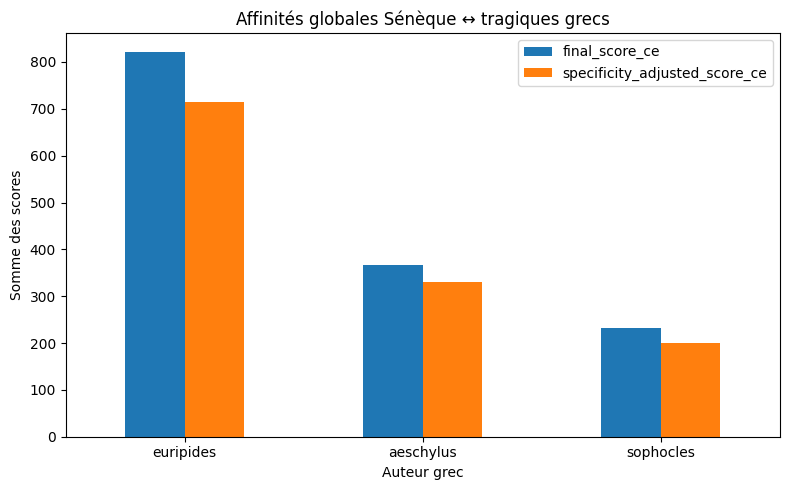

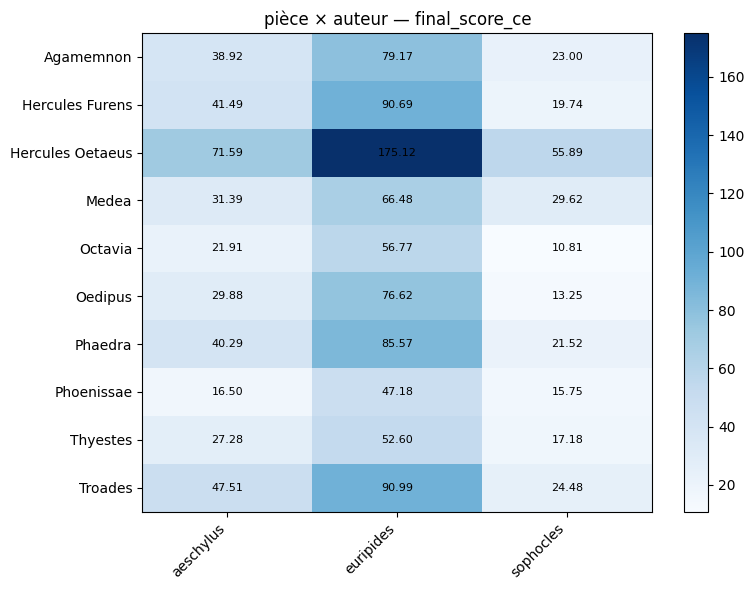

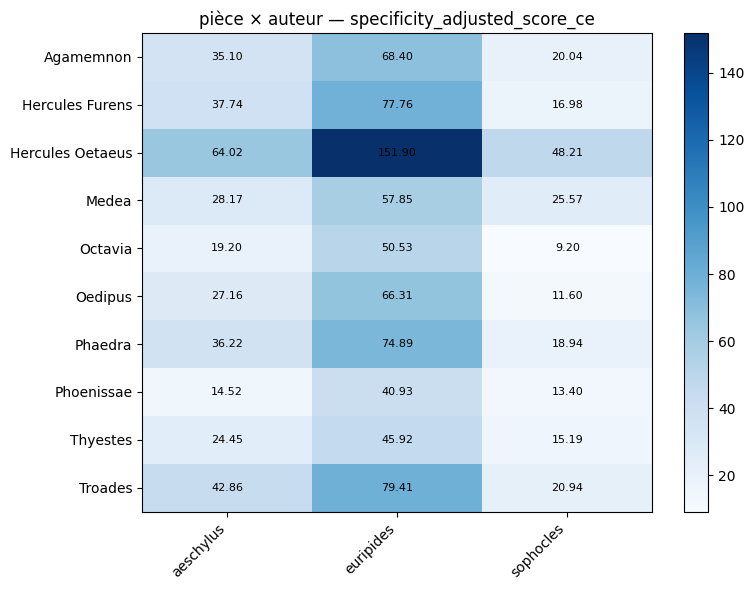

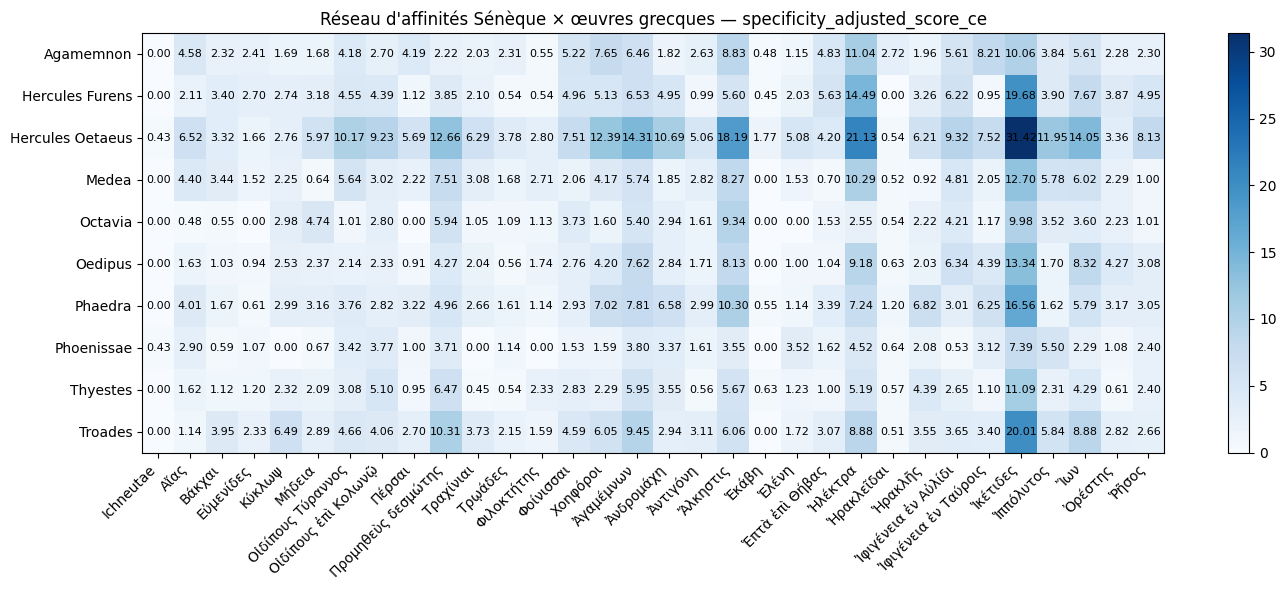

In [88]:
import matplotlib.pyplot as plt


def aggregate_by_author(df, score_col=None, adjusted_score_col=None):
    score_col = _resolve_score_col(df, score_col)
    adjusted_score_col = _resolve_adjusted_score_col(df, adjusted_score_col)
    return (
        df.groupby("target_author_group")
        .agg(
            n_matches=("source_segment_id", "count"),
            sum_score=(score_col, "sum"),
            sum_adjusted_score=(adjusted_score_col, "sum"),
        )
        .reset_index()
        .sort_values("sum_adjusted_score", ascending=False)
    )


def plot_heatmap_table(table, title, figsize=(8, 6), cmap="Blues"):
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(table.values, aspect="auto", cmap=cmap)
    ax.set_title(title)
    ax.set_xticks(np.arange(table.shape[1]))
    ax.set_yticks(np.arange(table.shape[0]))
    ax.set_xticklabels(table.columns)
    ax.set_yticklabels(table.index)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    for i in range(table.shape[0]):
        for j in range(table.shape[1]):
            ax.text(j, i, f"{table.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()


score_col = _resolve_score_col(final_candidates)
adjusted_score_col = _resolve_adjusted_score_col(final_candidates)

# Barplot auteur
author_agg = aggregate_by_author(final_candidates, score_col=score_col, adjusted_score_col=adjusted_score_col)
ax = author_agg.set_index("target_author_group")[["sum_score", "sum_adjusted_score"]].plot(
    kind="bar", figsize=(8, 5))
ax.set_title("Affinités globales Sénèque ↔ tragiques grecs")
ax.set_xlabel("Auteur grec")
ax.set_ylabel("Somme des scores")
ax.legend([score_col, adjusted_score_col])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Heatmap pièce × auteur
for col, title in [
    (score_col, f"pièce × auteur — {score_col}"),
    (adjusted_score_col, f"pièce × auteur — {adjusted_score_col}"),
]:
    table = pd.pivot_table(final_candidates, index="source_work_label",
                           columns="target_author_group", values=col,
                           aggfunc="sum", fill_value=0.0)
    plot_heatmap_table(table, title)

# Heatmap pièce × œuvre
heat_ww = pd.pivot_table(
    final_candidates, index="source_work_label", columns="target_work_label",
    values=adjusted_score_col, aggfunc="sum", fill_value=0.0
)
col_keep = heat_ww.sum(axis=0) > 0
plot_heatmap_table(
    heat_ww.loc[:, col_keep],
    f"Réseau d'affinités Sénèque × œuvres grecques — {adjusted_score_col}",
    figsize=(max(10, 0.45 * col_keep.sum()), 6),
)


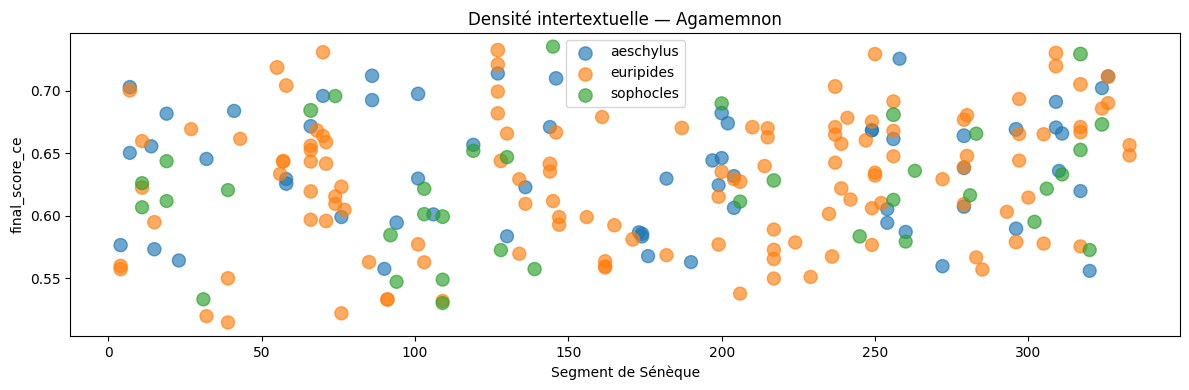

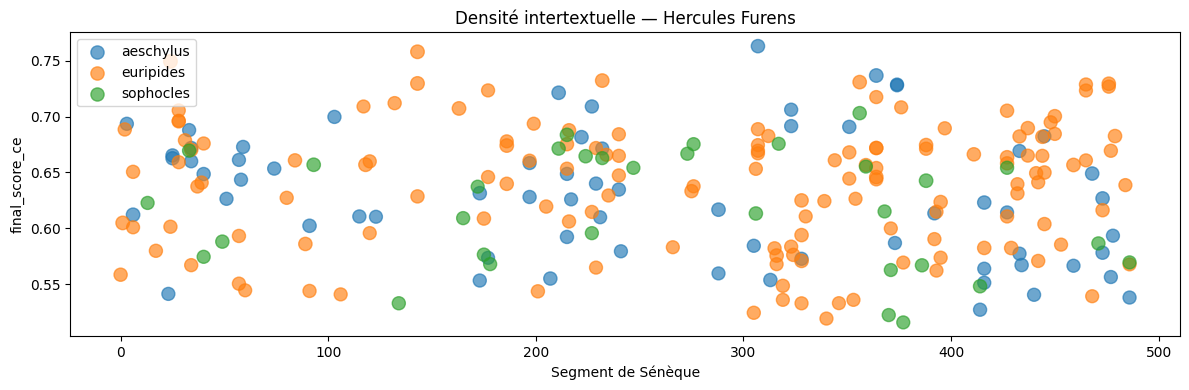

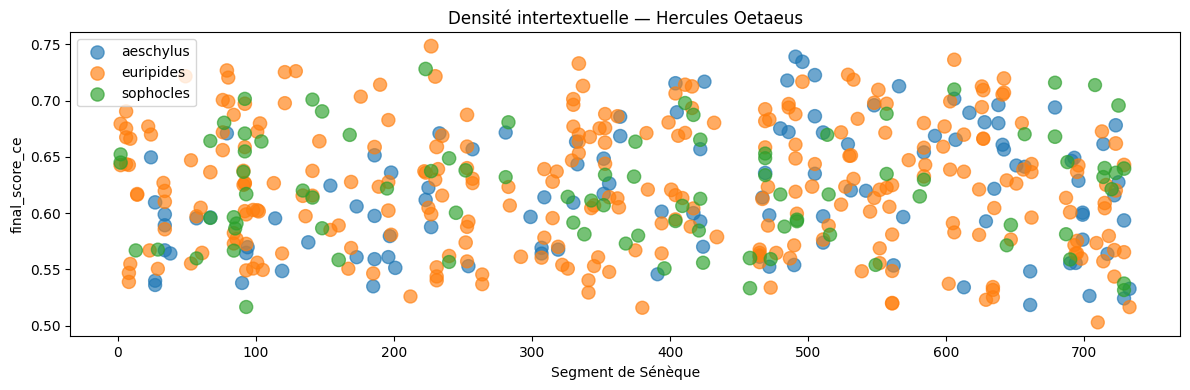

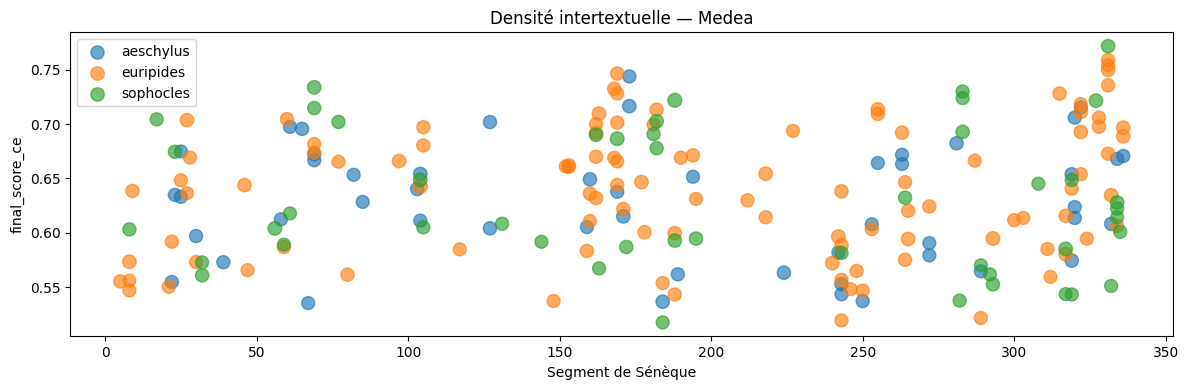

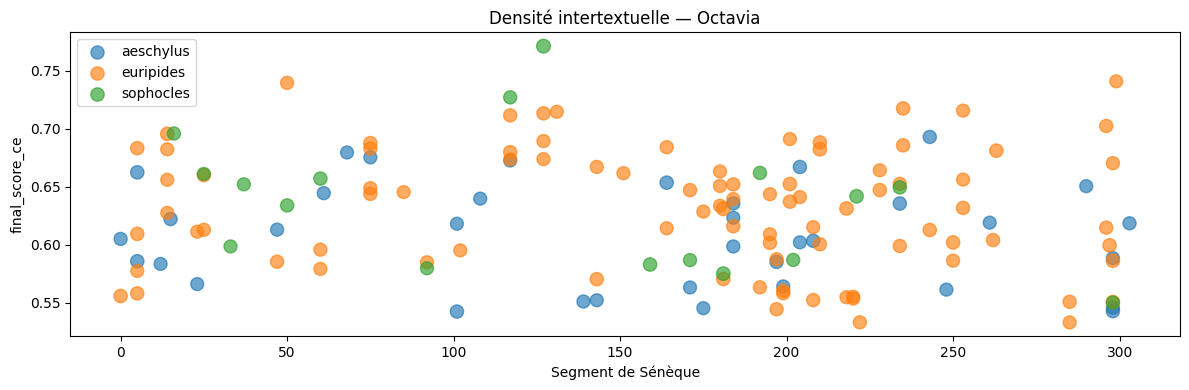

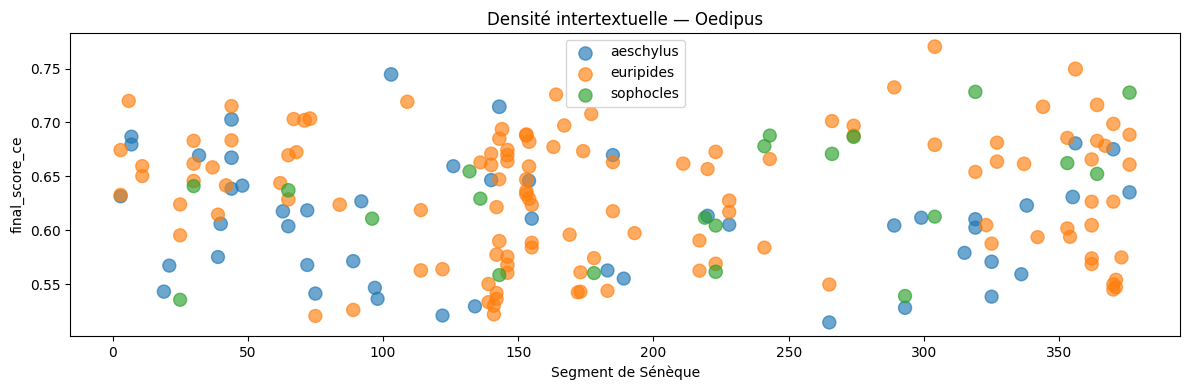

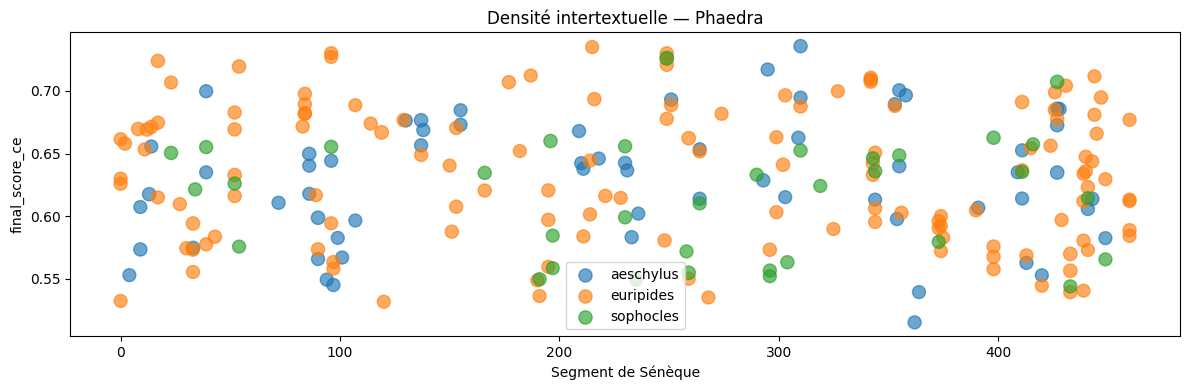

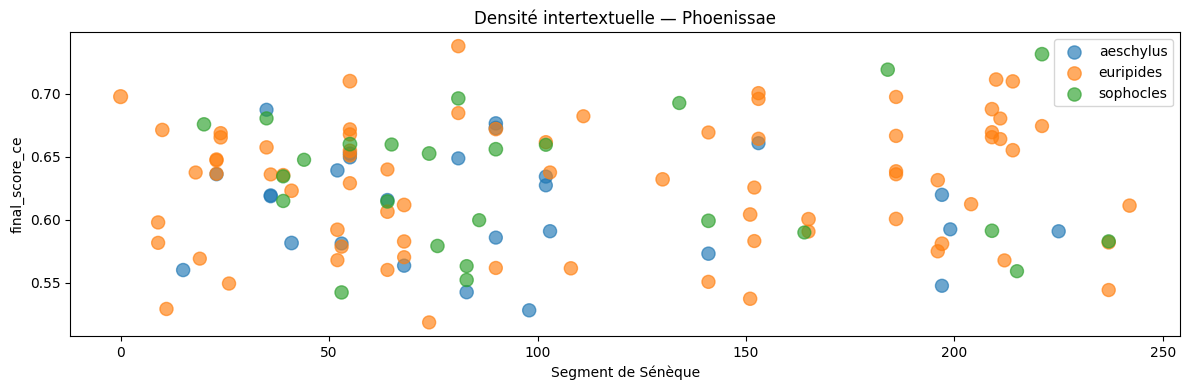

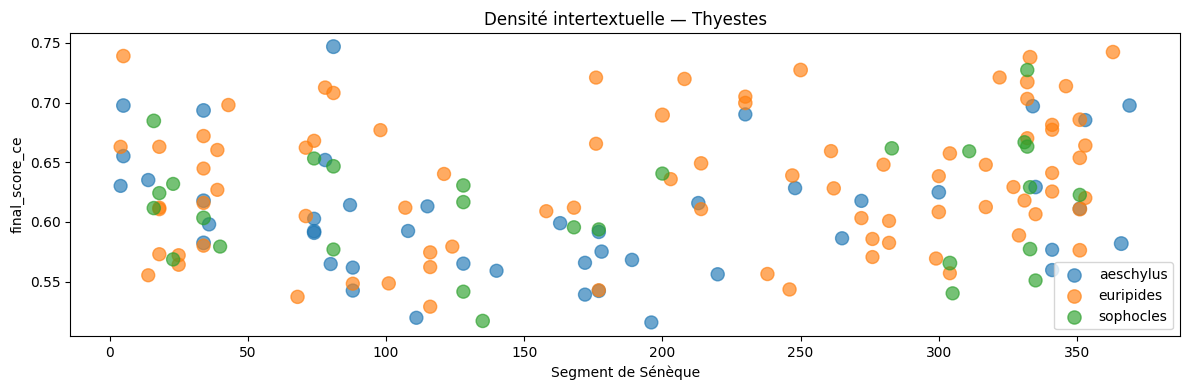

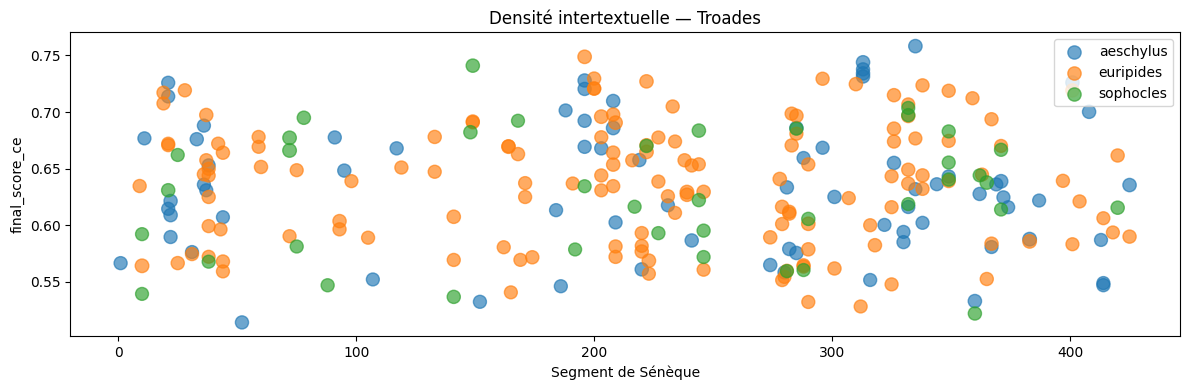

In [89]:
def plot_textual_density_by_work(df, work_label, score_col=None):
    score_col = _resolve_score_col(df, score_col)
    sub = df[df["source_work_label"] == work_label].copy()
    if sub.empty:
        print(f"Aucun candidat pour {work_label}.")
        return
    plt.figure(figsize=(12, 4))
    for author, part in sub.groupby("target_author_group"):
        plt.scatter(part["source_segment_idx"], part[score_col],
                    s=30 + 80 * part["sentence_similarity"].clip(0, 1),
                    alpha=0.65, label=author)
    plt.title(f"Densité intertextuelle — {work_label}")
    plt.xlabel("Segment de Sénèque")
    plt.ylabel(score_col)
    plt.legend()
    plt.tight_layout()
    plt.show()


for work in sorted(final_candidates["source_work_label"].unique()):
    plot_textual_density_by_work(final_candidates, work)


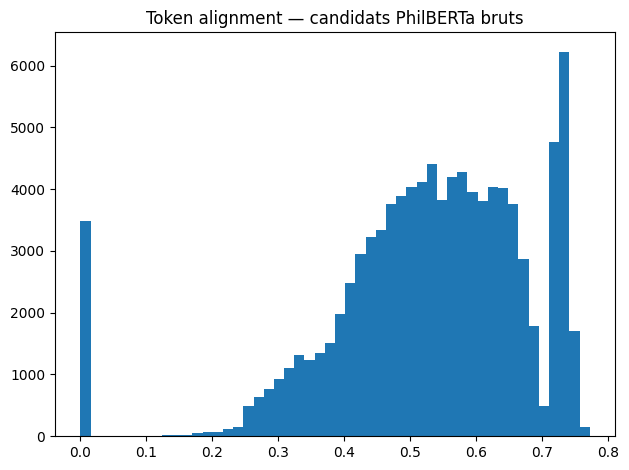

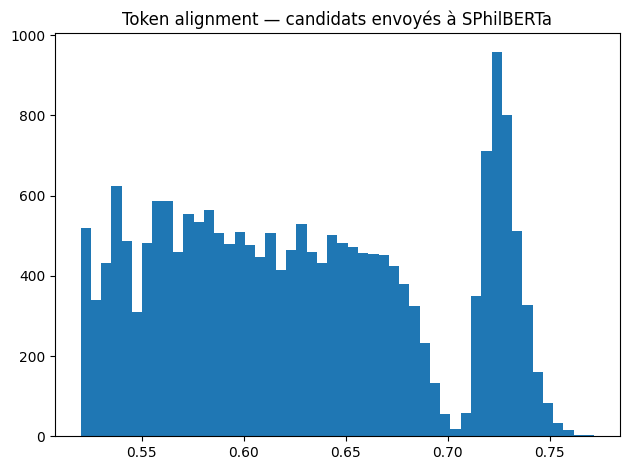

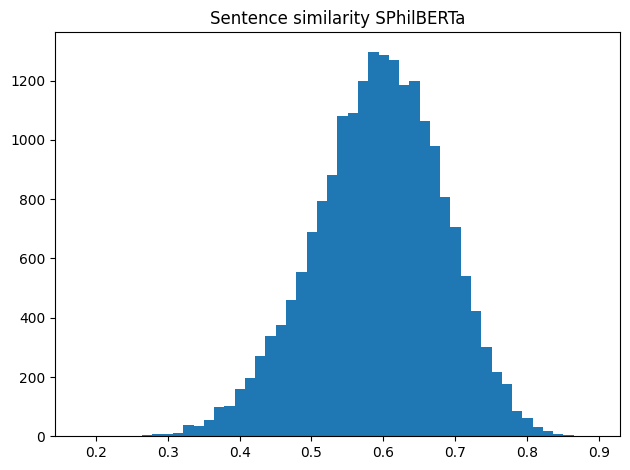

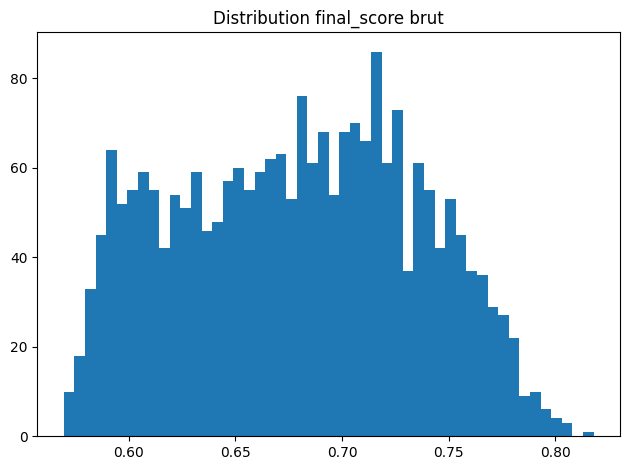

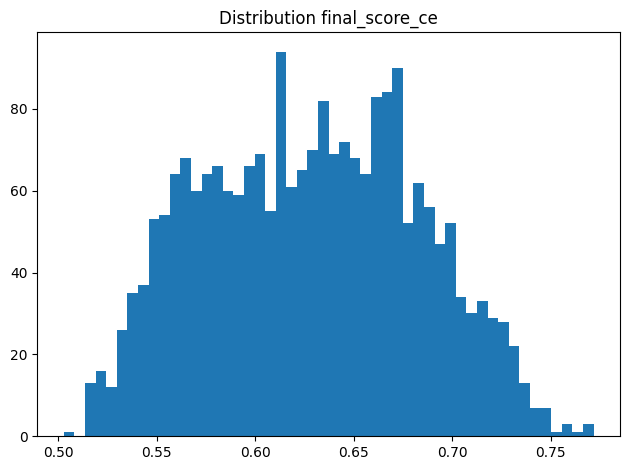

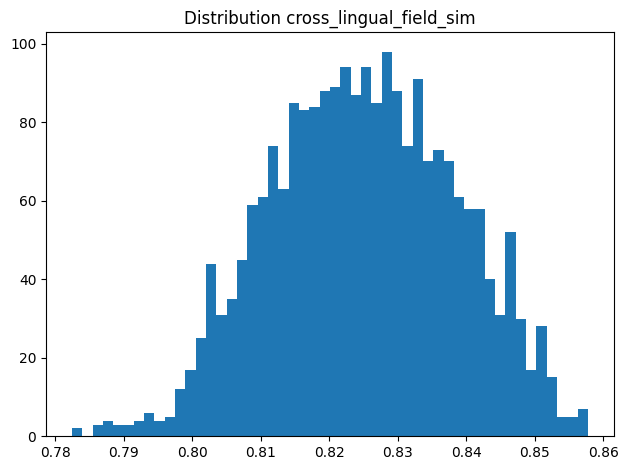

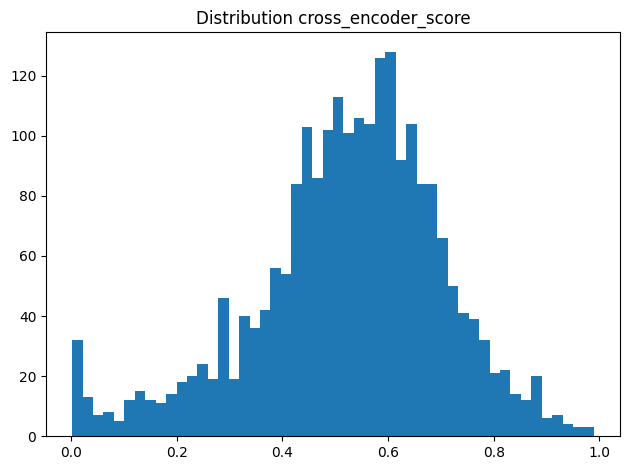

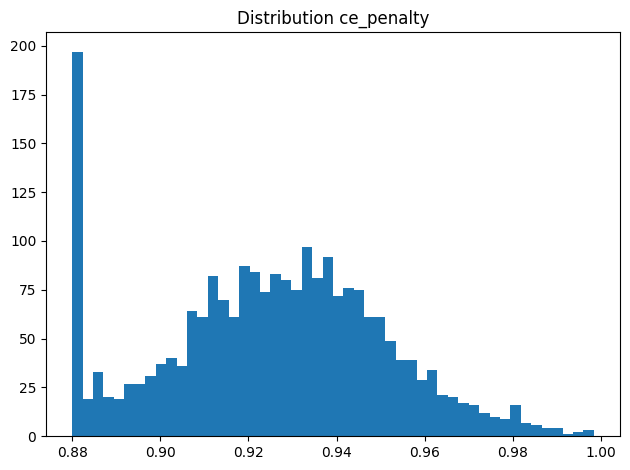

In [90]:
# Histogrammes diagnostiques
diagnostic_series = [
    (token_first_matches["token_alignment_score"],
     "Token alignment — candidats PhilBERTa bruts"),
    (token_first_matches_for_sphilberta["token_alignment_score"],
     "Token alignment — candidats envoyés à SPhilBERTa"),
    (sentence_reranked["sentence_similarity"],
     "Sentence similarity SPhilBERTa"),
    (final_candidates["final_score"],
     "Distribution final_score brut"),
    (final_candidates[FINAL_RANKING_SCORE_COL],
     f"Distribution {FINAL_RANKING_SCORE_COL}"),
    (final_candidates["cross_lingual_field_sim"],
     "Distribution cross_lingual_field_sim"),
]

if "cross_encoder_score" in final_candidates.columns:
    diagnostic_series.append(
        (final_candidates["cross_encoder_score"],
         "Distribution cross_encoder_score")
    )
    diagnostic_series.append(
        (final_candidates["ce_penalty"],
         "Distribution ce_penalty")
    )

for data, title in diagnostic_series:
    plt.figure()
    plt.hist(data, bins=50)
    plt.title(title)
    plt.tight_layout()
    plt.show()


## Exports


In [91]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

score_col = _resolve_score_col(final_candidates)
adjusted_score_col = _resolve_adjusted_score_col(final_candidates)

paths = {
    "final_candidates":           RESULTS_DIR / "final_candidates.csv",
    "token_for_sphilberta":       RESULTS_DIR / "token_first_for_sphilberta.csv",
    "summary_by_author":          RESULTS_DIR / "summary_by_author.csv",
    "top_cards_html":             RESULTS_DIR / "top_candidate_cards.html",
}

final_candidates.to_csv(paths["final_candidates"], index=False)
token_first_matches_for_sphilberta.to_csv(paths["token_for_sphilberta"], index=False)
summarize_by_author(final_candidates, score_col=score_col, adjusted_score_col=adjusted_score_col).to_csv(
    paths["summary_by_author"], index=False
)

html = "".join(
    candidate_card(row)
    for _, row in final_candidates.sort_values(score_col, ascending=False).head(100).iterrows()
)
paths["top_cards_html"].write_text(html, encoding="utf-8")

print("Exports sauvegardés :")
print(f"Score utilisé pour le tri HTML : {score_col}")
for name, p in paths.items():
    print(f"  {name:30s} → {p}")


Exports sauvegardés :
Score utilisé pour le tri HTML : final_score_ce
  final_candidates               → /content/results_tragic_influence/final_candidates.csv
  token_for_sphilberta           → /content/results_tragic_influence/token_first_for_sphilberta.csv
  summary_by_author              → /content/results_tragic_influence/summary_by_author.csv
  top_cards_html                 → /content/results_tragic_influence/top_candidate_cards.html
